# Assignment 1

## Simpel GDClassifier

### Förbered data

In [261]:
import os

pos_path = os.path.join("txt_sentoken", "pos")
neg_path = os.path.join("txt_sentoken", "neg")

pos_files = [os.path.join(pos_path, file) for file in os.listdir(pos_path)]
neg_files = [os.path.join(neg_path, file) for file in os.listdir(neg_path)]

X_raw = []
y = []
for filepath in pos_files:
    with open(filepath, "r", encoding="utf-8") as f:
        text = f.read()
        X_raw.append(text)
        y.append(1)

for filepath in neg_files:
    with open(filepath, "r", encoding="utf-8") as f:
        text = f.read()
        X_raw.append(text)
        y.append(-1)


In [262]:
import numpy as np

y = np.array(y)
print(y.shape)

assert len(X_raw) == 2000
assert np.all([isinstance(x, str) for x in X_raw])
assert len(X_raw) == y.shape[0], "All texts must be labelled!"
assert len(np.unique(y))==2, "Only two labels (1, -1) are allowed!"
assert y.min() == -1
assert y.max() == 1

assert y[0] == 1, "Positives must be first!"
assert y[-1] == -1, "Negatives must be last!"

(2000,)


### Split

Gjorde först misstaget att splitta utan att shuffla innan. Eftersom datan är sorterad med positiva först, så fick test-setet bara negativa medan train fick majoritet positive. Detta ledde till att train lärde modellerna att bli lat och bara gissa positiv på allt, vilket i sin tur ledde till att de sedan såklart fick 0% på test...

In [263]:
import numpy as np

indices = np.arange(len(X_raw)) # som range() fast numpy array så stödjer np seed & shuffle
np.random.seed(42)   # Reproducibility
np.random.shuffle(indices)

# Superviktigt att blanda X och y på samma sätt annars blir det ju fel labels!!!!
X_raw_shuffled = [X_raw[i] for i in indices]
y_shuffled = y[indices]

split_point = int(len(X_raw_shuffled) * 0.8)
X_train = X_raw_shuffled[:split_point]
X_test = X_raw_shuffled[split_point:]
y_train = y_shuffled[:split_point]
y_test = y_shuffled[split_point:]

print(f"Train: {np.sum(y_train==1)}/{len(y_train)} positive ({np.sum(y_train==1)/len(y_train)*100:.1f}%)")
print(f"Test: {np.sum(y_test==1)}/{len(y_test)} positive ({np.sum(y_test==1)/len(y_test)*100:.1f}%)")

assert len(y_train) + len(y_test) == len(y)
assert len(y_test) > 10

Train: 818/1600 positive (51.1%)
Test: 182/400 positive (45.5%)


### Bag-of-words vectorizer

We implement the binary bag of words.

In [264]:
import pickle
from tqdm import tqdm

class CountVectorizer: # = feature_transform()
    def __init__(self):
        self.vocabulary = []
        self.is_fitted_ = False

    def fit(self, X):
        vocab = set()
        for review in X:
            vocab.update(review.split())
        self.vocabulary.extend(sorted(vocab)) # sorted returns a list
        self.is_fitted_ = True
        return self

    def transform(self, X):
        bag_of_words_array = []
        for review in tqdm(X):
            words = set(review.split())
            vector = [int(x in words) for x in self.vocabulary]
            # första gången glömde jag .split() så att det var enskilda bokstäver, men fick ändå 99+% accuracy... :O
            # andra gången blev det för seft eftersom split varken sparades eller hashades i ett set...
            #vector = [int(bool(x in review.split())) for x in self.vocabulary] 
            # det tog flera timmar, men nu tar det 5 sekunder :) #thatfeelingwhen
            bag_of_words_array.append(vector)

        return np.array(bag_of_words_array)
    
    def get_feature_names_out(self):
        if self.is_fitted_:
            return np.array(self.vocabulary)

vectorizer = CountVectorizer()
vectorizer.fit(X_train)             # Creates the vocabulary of the vectorizer
assert len(vectorizer.vocabulary) != 0, "Empty vocab!"

pkl_path = os.path.join("txt_sentoken", "vectors.pkl")
if os.path.exists(pkl_path):
    with open(pkl_path, "rb") as f:
        X_train_bow, X_test_bow = pickle.load(f)
else:
    X_train_bow = vectorizer.transform(X_train)
    X_test_bow = vectorizer.transform(X_test)
    with open(pkl_path, "wb") as f:
        pickle.dump((X_train_bow, X_test_bow), f)

In [265]:
ordered_vocabulary = vectorizer.get_feature_names_out()
print(ordered_vocabulary)
vocabulary = set(ordered_vocabulary)

assert np.isin(X_train_bow, [0, 1]).all(), "Non binary value in the train bag-of-words matrix!"
assert np.isin(X_test_bow, [0, 1]).all(), "Non binary value in the test bag-of-words matrix!"

print(f"Train shape: {X_train_bow.shape}")
print(f"Test shape: {X_test_bow.shape}")

assert X_train_bow.shape[1] == X_test_bow.shape[1], "Train and test differ in vocab!"
assert X_train_bow.shape[1] == len(ordered_vocabulary), "The bag-of-words contains more words than the vocab!"

['\x05' '\x13goodies' '\x13suspend' ... "zwigoff's" '|' '||']
Train shape: (1600, 45773)
Test shape: (400, 45773)


In [266]:
lut = dict()
for i, word in enumerate(ordered_vocabulary):
  lut[word] = i

for word in ['a', 'dolphin', 'the', 'coffee']:
  if word in vocabulary:
    print("'%s' is represented as feature dimension %i" %(word, lut[word]))
  else:
    print("'%s' is not in the vocabulary" % word)

'a' is represented as feature dimension 1622
'dolphin' is represented as feature dimension 12408
'the' is represented as feature dimension 40798
'coffee' is represented as feature dimension 8614


### Enkel GD-klassificerare

Vi slutar träna när $loss_{best} - loss_{current} > n$ för någon toleransnivå $n$, t.ex. $0.001$, under $m$ iterationer i rad, för någon tålamodsnivå $m$. Med andra ord, när lossen inte minskar tillräckligt mycket tillräckligt snabbt. Vid mitt första försök lyckades jag invertera denna lite kluriga olikhet, vilket gör att det inte konvergerar.

Det i särklass svåraste var dock att få till shapes för `X` och `_omega` och hålla tungan rätt i mun när man itererar över `X`, eftersom `_omega` ska stämma överens i dimensioner med raderna, dvs. `X.shape[1] == self._omega.shape[0]`. Just detta tog mig väldigt många försök att få rätt konsekvent genom alla methods.

Några python-metoder behövde jag lära mig för första gången. Till exempel behövde jag inse att `np.inf` existerade, innan jag kom på ett icke-godtyckligt sätt att initialisera `best_loss`, och jag lärde mig använda `np.concatenate` för att lägga till nya rader till existerande matriser.

In [267]:
class GDClassifier:
  '''This version is not called "stochastic" since the gradient comes from all the data every time...'''
  def __init__(self, regularizer_dampening=0.001, verbose=True, learning_rate=0.0001, tolerance=0.001, patience=5):
    self.regularizer_dampening = regularizer_dampening
    self.verbose = verbose
    self.learning_rate = learning_rate
    self.tolerance = tolerance
    self.patience = patience

    self._omega = np.zeros(0) # initialization
    self.loss_ = []

  def fit(self, X, y):
    # add a row of pseudo-inputs
    X = self._add_pseudo_iput(X)

    feature_dims = X.shape[1] # vocabulary len + 1

    self._omega = np.zeros(feature_dims) # we need parameters for every feature dimension 
    self._omega += np.random.normal(size=feature_dims) # place at a random place in the loss landscape

    assert self._omega.shape[0] == feature_dims # the shape of a feature vector needs to equal the parameter vector to do matmul

    running_out_of_patience_in = self.patience
    best_loss = np.inf # to make sure we don't start running out of patience immediately 
    iteration = 0
    while running_out_of_patience_in > 0:
      iteration += 1
      current_loss = self._fit(X, y)
      if self.verbose:
        print(f"{iteration}: {current_loss:.0f}")
      self.loss_.append(current_loss)
      if best_loss - current_loss > self.tolerance: # if loss improves enough, we set a new best and reset patience
        best_loss = current_loss
        running_out_of_patience_in = self.patience
      else:
        running_out_of_patience_in -= 1 # if loss does not improve enough, we run out of patience
        if self.verbose:
          print(f"Patience: {running_out_of_patience_in}")
    
    return self # scikit-learn convention that "fit" returns itself

  def predict(self, X):
    '''Crisp predictions, unlike the prediction used in the hinge loss'''
    X = self._add_pseudo_iput(X)
    y_hat = np.sign(X @ self._omega) # note the commuted order to avoid looping over self._omega @ X[i,:]
    assert y_hat.shape == (X.shape[0],) # one prediction per input text
    
    return y_hat

  def score(self, X, y) -> float:
    '''
    Hinge loss with l2 regularization.
    y are the correct labels.
    Outputs a positive float.
    '''
    regularization_term = self.regularizer_dampening/2 * np.sum(np.square(self._omega))
    raw_y_hat = X @ self._omega # uncrisp prediction. X comes first since X.shape = (1600, 46181) and _omega.shape = (46181,)
    hinge_loss_term = np.sum(np.maximum(0, 1 - y * raw_y_hat)) # a numpy function that from two input arrays a and b with the same shape returns an array c where c_ij = max(a_ij, b_ij)
    loss = regularization_term + hinge_loss_term
    
    assert isinstance(loss, float)
    assert loss >= 0

    return loss
  
  def _fit(self, X, y):
    self._omega -= self.learning_rate * self._hinge_gradient(X, y)
    return self.score(X, y)

  def _hinge_gradient(self, X, y):
    assert X.shape[0] == y.shape[0] # 1600
    assert X.shape[1] == self._omega.shape[0] # confirms that omega was initialized with the right dims

    regularization_term = self.regularizer_dampening * self._omega
    gradient = regularization_term # initialize the gradient with the first term
    for i in range(X.shape[0]): # loop over n samples
      raw_y_hat_i = self._omega @ X[i, :] # (46181,) @ (46181,)
      if y[i] * raw_y_hat_i >= 1:
        continue # i.e. add 0
      else:
        gradient -= y[i] * X[i]
    return gradient
  
  def _add_pseudo_iput(self, X):
    '''Add a row of pseudo-inputs'''
    n = X.shape[0]
    pseudo_input = np.ones(shape=(n, 1))
    X = np.concatenate([X, pseudo_input], axis=1) # hacky but elegant alternative: X = np.c_[X, pseudo_input]

    return X
  

1: 11836
2: 11772
3: 11709
4: 11645
5: 11582
6: 11521
7: 11459
8: 11398
9: 11337
10: 11277
11: 11217
12: 11157
13: 11098
14: 11039
15: 10980
16: 10922
17: 10865
18: 10808
19: 10750
20: 10694
21: 10637
22: 10581
23: 10526
24: 10471
25: 10416
26: 10362
27: 10308
28: 10254
29: 10201
30: 10147
31: 10095
32: 10043
33: 9991
34: 9940
35: 9889
36: 9839
37: 9789
38: 9739
39: 9690
40: 9641
41: 9593
42: 9545
43: 9497
44: 9450
45: 9403
46: 9356
47: 9309
48: 9263
49: 9217
50: 9172
51: 9127
52: 9082
53: 9037
54: 8993
55: 8949
56: 8905
57: 8862
58: 8819
59: 8776
60: 8733
61: 8690
62: 8648
63: 8605
64: 8563
65: 8521
66: 8480
67: 8439
68: 8399
69: 8359
70: 8320
71: 8282
72: 8244
73: 8206
74: 8168
75: 8130
76: 8093
77: 8056
78: 8019
79: 7983
80: 7947
81: 7910
82: 7874
83: 7839
84: 7803
85: 7768
86: 7732
87: 7697
88: 7663
89: 7628
90: 7593
91: 7559
92: 7524
93: 7490
94: 7456
95: 7423
96: 7389
97: 7356
98: 7323
99: 7289
100: 7257
101: 7225
102: 7193
103: 7162
104: 7130
105: 7099
106: 7068
107: 7037
108: 7

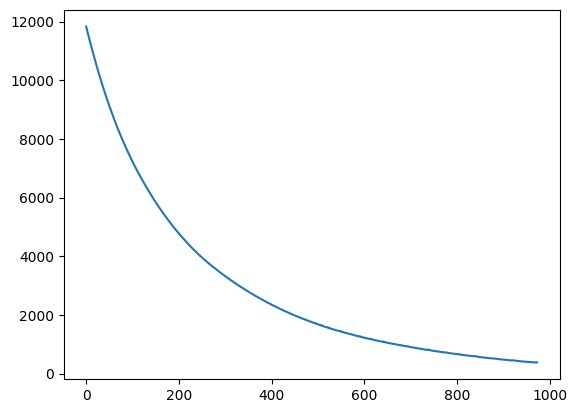

In [268]:
# Set hyperparameters
regularizer_dampening = 0.001   # λ
learning_rate = 0.0001          # γ with order of magnitude e-3 and larger does not seem to converge (before my own patience runs out)

# Create the untrained classifier
model = GDClassifier(regularizer_dampening=regularizer_dampening,
                      learning_rate=learning_rate)

# Train the classifier
model.fit(X_train_bow, y_train)

# Get the parameter vector
omega = model._omega

# Plot the loss curve
loss = model.loss_

import matplotlib.pyplot as plt

plt.plot(loss)
plt.show()


Vikterna är mycket mer jämnt fördelade än i Fredriks sklearn-impementation. Känns som att det betyder att en del skräp har fått onödigt höga vikter. 

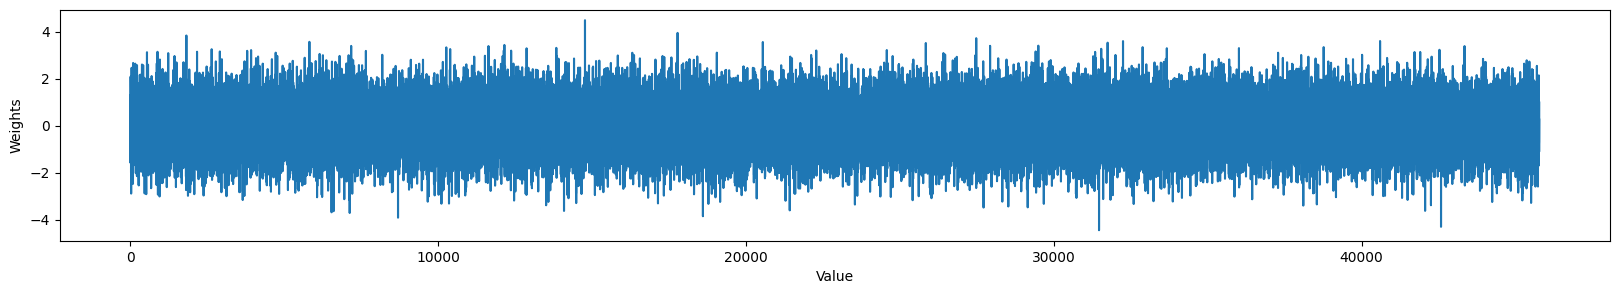

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 3))
plt.plot(omega[1:])
plt.xlabel("Value")
plt.ylabel("Weights")
plt.show()

Lot's of words with 1 occurance are getting high weights, which is of course useless for generalization. I suspect some of these are specific to certain movie titles that appear in only a single review, and hence get overtrained.

In [270]:
assert (len(omega)-1) == len(vocabulary)

# Sort by absolute value
idx = np.argsort(np.abs(omega[1:]))

print("                Word   Weight  Occurences")
for i in idx[-30:]:   # Pick those with highest 'voting' values
  print("%20s   %.3f\t%i " % (ordered_vocabulary[i], omega[i+1], np.sum([ordered_vocabulary[i] in d for d in X_raw])))

                Word   Weight  Occurences
           carousing   3.387	2 
             nolan's   3.391	1 
    twenty-something   -3.392	4 
             elitism   -3.393	2 
        pacification   3.398	1 
             sounded   -3.407	15 
          dissection   3.429	2 
             oedipal   -3.446	2 
             outdone   -3.481	4 
                nice   -3.491	354 
          mesmerizes   3.511	1 
            primeval   3.525	1 
           immigrant   3.553	13 
               boris   3.562	7 
               pubic   3.592	1 
           templeton   3.596	2 
        intermission   -3.611	2 
            true-man   -3.631	1 
               erich   -3.635	26 
           burlesque   -3.645	2 
             bumping   -3.693	3 
                 ned   3.716	1289 
              caress   -3.723	2 
           accolades   3.830	8 
            hang-out   -3.860	1 
          collection   -3.922	61 
               grabs   3.942	14 
    uncompromisingly   -4.310	1 
      pre-production   -4.455	3 
    

### Hyperparameteroptimisering

Såg vid första körningarna att alla bra parametrar var <= e-4, och för lr t.o.m. <= e-5, så har anpassat gränserna för `logspace`. Vid dessa låga lrs är konvergensen dock *mycket* långsam, så orkar inte vänta på e-6.

In [272]:
from collections import defaultdict
from tqdm import tqdm

def get_best_hyperparams(n_samples=10):
  global acc_grid
  acc_grid = defaultdict(dict) # I like defaultdicts

  best_hyperparameters = None

  rand_gen = np.random.default_rng() # stod i np manualen att detta var den senaste syntaxen
  for learning_rate, regularizer_dampening in tqdm(zip(rand_gen.choice(np.linspace(0.00001, 0.000099, num=100), n_samples),
                                                rand_gen.choice(np.logspace(-5, -4, num=100, base=10.0), n_samples)), total=n_samples):

    model = GDClassifier(regularizer_dampening=regularizer_dampening, 
                          verbose=True,
                          learning_rate=learning_rate)

    print(f"\nTesting hyperparameters: learning_rate={learning_rate:.6f}, regularizer_dampening={regularizer_dampening:.6f}")
    print("Fitting...")
    model.fit(X_train_bow, y_train)

    print("Evaluating...")
    training_accuracy = np.sum(model.predict(X_train_bow)==y_train)/len(y_train)

    acc_grid[learning_rate][regularizer_dampening] = training_accuracy # outer and inner dicts

    if best_hyperparameters is None or best_hyperparameters[2] < training_accuracy:
      best_hyperparameters = (learning_rate, regularizer_dampening, training_accuracy)
      print("%.7f\t\t%.7f\t\t%.2f%%" % (learning_rate, regularizer_dampening, 100*training_accuracy))
    
  return best_hyperparameters

best_learning_rate_gd, best_regularizer_dampening_gd, best_accuracy_gd = get_best_hyperparams(n_samples=10)

print(f"Best parameters: learning rate = %.6f, regularizer dampening = %.6f, accuracy = %.2f%%" % (best_learning_rate_gd, best_regularizer_dampening_gd, 100*best_accuracy_gd))

  0%|          | 0/10 [00:00<?, ?it/s]


Testing hyperparameters: learning_rate=0.000016, regularizer_dampening=0.000022
Fitting...
1: 11567
2: 11516
3: 11466
4: 11418
5: 11373
6: 11331
7: 11293
8: 11257
9: 11225
10: 11194
11: 11165
12: 11138
13: 11112
14: 11088
15: 11067
16: 11046
17: 11025
18: 11005
19: 10986
20: 10968
21: 10951
22: 10934
23: 10917
24: 10902
25: 10886
26: 10872
27: 10858
28: 10845
29: 10833
30: 10820
31: 10808
32: 10796
33: 10784
34: 10772
35: 10761
36: 10749
37: 10738
38: 10727
39: 10716
40: 10705
41: 10694
42: 10683
43: 10673
44: 10662
45: 10651
46: 10641
47: 10630
48: 10620
49: 10610
50: 10599
51: 10589
52: 10579
53: 10568
54: 10558
55: 10548
56: 10538
57: 10528
58: 10518
59: 10508
60: 10497
61: 10487
62: 10477
63: 10467
64: 10457
65: 10447
66: 10437
67: 10428
68: 10418
69: 10408
70: 10398
71: 10388
72: 10378
73: 10369
74: 10359
75: 10349
76: 10340
77: 10330
78: 10320
79: 10311
80: 10301
81: 10291
82: 10282
83: 10272
84: 10263
85: 10253
86: 10244
87: 10234
88: 10224
89: 10215
90: 10205
91: 10196
92: 101

 10%|█         | 1/10 [03:54<35:08, 234.28s/it]

7665: 103
Patience: 1
7666: 106
Patience: 0
Evaluating...
0.0000163		0.0000215		98.69%

Testing hyperparameters: learning_rate=0.000095, regularizer_dampening=0.000032
Fitting...
1: 14587
2: 13022
3: 12129
4: 11621
5: 11334
6: 11177
7: 11075
8: 10997
9: 10929
10: 10867
11: 10810
12: 10756
13: 10702
14: 10649
15: 10597
16: 10545
17: 10494
18: 10444
19: 10394
20: 10344
21: 10295
22: 10246
23: 10197
24: 10148
25: 10099
26: 10050
27: 10001
28: 9953
29: 9905
30: 9857
31: 9809
32: 9762
33: 9716
34: 9670
35: 9623
36: 9578
37: 9532
38: 9486
39: 9441
40: 9396
41: 9351
42: 9307
43: 9263
44: 9220
45: 9177
46: 9135
47: 9093
48: 9051
49: 9009
50: 8968
51: 8927
52: 8886
53: 8845
54: 8806
55: 8766
56: 8727
57: 8688
58: 8650
59: 8612
60: 8574
61: 8537
62: 8499
63: 8462
64: 8425
65: 8389
66: 8353
67: 8317
68: 8282
69: 8247
70: 8212
71: 8177
72: 8142
73: 8107
74: 8073
75: 8039
76: 8005
77: 7970
78: 7937
79: 7903
80: 7870
81: 7837
82: 7805
83: 7772
84: 7740
85: 7708
86: 7676
87: 7645
88: 7613
89: 7582
90

 20%|██        | 2/10 [04:28<15:33, 116.72s/it]

...

962: 524
Patience: 1
963: 537
Patience: 0
Evaluating...

Testing hyperparameters: learning_rate=0.000023, regularizer_dampening=0.000013
Fitting...
1: 12224
2: 12162
3: 12102
4: 12049
5: 12001
6: 11958
7: 11918
8: 11882
9: 11851
10: 11821
11: 11795
12: 11770
13: 11747
14: 11725
15: 11704
16: 11684
17: 11666
18: 11649
19: 11632
20: 11616
21: 11600
22: 11585
23: 11570
24: 11555
25: 11540
26: 11526
27: 11512
28: 11498
29: 11484
30: 11470
31: 11456
32: 11443
33: 11429
34: 11416
35: 11402
36: 11389
37: 11376
38: 11363
39: 11350
40: 11337
41: 11324
42: 11311
43: 11298
44: 11286
45: 11273
46: 11260
47: 11247
48: 11235
49: 11222
50: 11209
51: 11196
52: 11184
53: 11171
54: 11158
55: 11146
56: 11133
57: 11120
58: 11108
59: 11095
60: 11083
61: 11070
62: 11058
63: 11046
64: 11033
65: 11021
66: 11009
67: 10996
68: 10984
69: 10972
70: 10960
71: 10947
72: 10935
73: 10923
74: 10911
75: 10898
76: 10886
77: 10874
78: 10862
79: 10850
80: 10838
81: 10826
82: 10813
83: 10801
84: 10789
85: 10777
86: 10765
8

 90%|█████████ | 9/10 [12:31<01:31, 91.68s/it]

6688: 42
6689: 42
Patience: 4
6690: 43
Patience: 3
6691: 48
Patience: 2
6692: 42
Patience: 1
6693: 42
Patience: 0
Evaluating...
0.0000226		0.0000132		99.44%

Testing hyperparameters: learning_rate=0.000072, regularizer_dampening=0.000035
Fitting...
1: 13620
2: 12906
3: 12425
4: 12102
5: 11882
6: 11728
7: 11605
8: 11515
9: 11447
10: 11388
11: 11336
12: 11287
13: 11240
14: 11194
15: 11148
16: 11102
17: 11058
18: 11013
19: 10968
20: 10924
21: 10880
22: 10837
23: 10794
24: 10752
25: 10711
26: 10669
27: 10628
28: 10587
29: 10546
30: 10505
31: 10465
32: 10425
33: 10385
34: 10346
35: 10307
36: 10268
37: 10229
38: 10191
39: 10153
40: 10116
41: 10079
42: 10042
43: 10005
44: 9968
45: 9932
46: 9896
47: 9861
48: 9825
49: 9790
50: 9755
51: 9720
52: 9685
53: 9651
54: 9617
55: 9583
56: 9549
57: 9515
58: 9481
59: 9448
60: 9416
61: 9384
62: 9352
63: 9320
64: 9288
65: 9257
66: 9225
67: 9194
68: 9163
69: 9132
70: 9101
71: 9071
72: 9040
73: 9010
74: 8980
75: 8950
76: 8920
77: 8890
78: 8861
79: 8831
80: 88

100%|██████████| 10/10 [13:20<00:00, 80.03s/it]

1580: 222
Patience: 3
1581: 231
Patience: 2
1582: 222
Patience: 1
1583: 231
Patience: 0
Evaluating...
Best parameters: learning rate = 0.000023, regularizer dampening = 0.000013, accuracy = 99.44%


In [273]:
from tabulate import tabulate # för att slippa printa all tabellens ascii-art manuellt

lambdas = set()
for inner_dict in acc_grid.values():
    lambdas.update(inner_dict.keys()) # update is like append but for sets

lrs = sorted(acc_grid.keys()) # the keys are lrs only because its a nested dictionary
lambdas = sorted(lambdas)

headers = ["lr \\ lambda"] + [f"{lam:.1e}" for lam in lambdas] # elementet (0,0) i griden har ingen kombination 

rows = []

for lr in lrs:
    row = [f"{lr:.1e}"] # första kolumnen har lr-headers
    for lam in lambdas:
        inner = acc_grid.get(lr)
        acc = None if inner is None else inner.get(lam)
        row.append("" if acc is None else f"{acc*100:.2f}%")
    rows.append(row)

print(tabulate(rows, headers=headers, tablefmt="grid"))

+---------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+
|   lr \ lambda | 1.3e-05   | 1.7e-05   | 2.2e-05   | 2.4e-05   | 3.2e-05   | 3.5e-05   | 3.8e-05   | 5.0e-05   | 5.1e-05   | 7.6e-05   |
+===============+===========+===========+===========+===========+===========+===========+===========+===========+===========+===========+
|       1.6e-05 |           |           | 98.69%    |           |           |           |           |           |           |           |
+---------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+
|       2.3e-05 | 99.44%    |           |           |           |           |           |           |           |           |           |
+---------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+
|       3.2e-05 |           |     

In [274]:
# Set up the classifier
model = GDClassifier(regularizer_dampening=best_regularizer_dampening, 
                    verbose=True,
                    learning_rate=best_learning_rate)

# Train on all the non-test data
model.fit(X_train_bow, y_train)

# Run prediction on the test set
test_accuracy = np.sum(model.predict(X_test_bow)==y_test)/len(y_test)

print("Test set accuracy %.1f%%" % (100*test_accuracy))

NameError: name 'best_regularizer_dampening' is not defined

## Implementation 2

Här implementerar succesivt en `SGDClassifier` med

- stochastisk mini-batch gradient descent
- ExponentialLR learning-rate scheduler, med en decay rate som hyperparameter (https://machinelearningmastery.com/a-gentle-introduction-to-learning-rate-schedulers/). Kräver bara tre små ändringar i koden.

Vi börjar dock med en *term frequency–inverse document frequency*-vektoriserare:

### TF-IDF

Här skapar vi en vektoriserare med TF-IDF-vikter. Under arbetet har jag lärt mig den hårda vägen att sets är hash tables (keys länkade direkt till platser i minnet) i python medan lists är linjära, så att kolla efter en term bland `n` termer i `set(vocabulary)` tar en enda operation, medan att kolla efter t i list(vocabulary) tar n operationer, dvs. vi har O(1) och O(n). När jag implementerat att iterera över vocab som ett set i `transform()` tog det 7.1s att embedda alla 2000 dokument, och i min första generation tog mer än ett dygn!!!

In [ ]:
from collections import defaultdict, Counter
from tqdm import tqdm

class CountVectorizerTFIDF:
    '''
    tf räknar ord
    tf = antal förekomster av term t i dokument d, över totalt antal ord (med dubletter) i d

    idf räknar dokument
    idf = log av kvoten mellan totalt antal dokument N och antal dokument n_t innehållandes t
    '''
    def __init__(self):
        self.vocabulary = []
        self.idf_ = {}
        self.is_fitted_ = False

    def fit(self, X):
        '''
        Hitta vocab med en iteration genom alla docs och sen idf med en iteration genom vokabulären.
        '''
        vocab = set()
        doc_freq = defaultdict(int)

        for doc in X: # kombinera vocab och idf i samma loop för att slippa iterera genom alla dokument flera gånger
            terms = set(doc.split())
            vocab.update(terms)
            for term in terms:
                doc_freq[term] += 1 # vi räknar n_t för alla t

        self.vocabulary = sorted(vocab) # sorted returns a list

        N = len(X)
        for term in self.vocabulary:
            n_t = doc_freq[term] # färdigräknat
            idf = np.log(N / n_t)
            self.idf_[term] = idf

        self.is_fitted_ = True
        return self

    def transform(self, X):
        '''
        updated
        '''
        bag_of_words_array = []
        vocabulary_set = set(self.vocabulary)
        
        for doc in tqdm(X):
            terms = doc.split()
            counter = Counter(terms)
            tf_idf_weight = defaultdict(int) # set default to zero
            for t in counter:
                if t in vocabulary_set:
                    tf = counter[t] / counter.total() # .total() ger just totalt antal ord med dubletter
                    idf = self.idf_[t]
                    tf_idf = tf * idf
                    tf_idf_weight[t] = tf_idf
            vector = [tf_idf_weight.get(term, 0.0) for term in self.vocabulary]
            #print(vector)
            #print(len([float(digit) for digit in vector if digit > 0]), f"non-zero values out of {len(vector)}")
            bag_of_words_array.append(vector)

        return np.array(bag_of_words_array)
    
    def get_feature_names_out(self):
        if self.is_fitted_:
            return np.array(self.vocabulary)

In [ ]:
import pickle

vectorizer = CountVectorizerTFIDF()
vectorizer.fit(X_train)             # Creates the vocabulary of the vectorizer
assert len(vectorizer.vocabulary) != 0, "Empty vocab!"

# Pickle för snabbare tester

pkl_path = os.path.join("txt_sentoken", "vectors_tfidf.pkl")
if os.path.exists(pkl_path):
    with open(pkl_path, "rb") as f:
        X_train_tfidf, X_test_tfidf = pickle.load(f)
else:
    X_train_tfidf = vectorizer.transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    with open(pkl_path, "wb") as f:
        pickle.dump((X_train_tfidf, X_test_tfidf), f)

100%|██████████| 400/400 [00:01<00:00, 384.54it/s]


### Mini-batch SGD classifier

Batchingen innebär bara en uppdatering av `_fit()`.

In [ ]:
class SGDClassifier:
  '''This version is truly "stochastic" since the gradient is calculated from random batches.'''
  def __init__(self, regularizer_dampening=0.001, verbose=True, learning_rate=0.1, tolerance=0.004, patience=10, batches=10):
    self.regularizer_dampening = regularizer_dampening
    self.verbose = verbose
    self.learning_rate = learning_rate
    self.tolerance = tolerance
    self.patience = patience
    self.batches = batches

    self.current_batch = 0

    self._omega = np.zeros(0)
    self.loss_ = []

  def fit(self, X, y):
    X = self._add_pseudo_iput(X)

    feature_dims = X.shape[1]

    self._omega = np.zeros(feature_dims)
    self._omega += np.random.normal(size=feature_dims)

    assert self._omega.shape[0] == feature_dims

    running_out_of_patience_in = self.patience
    best_loss = np.inf
    iteration = 0
    while running_out_of_patience_in > 0:
      iteration += 1
      current_loss = self._fit(X, y)
      if self.verbose:
        print(f"{iteration} (batch {self.current_batch + 1}/{self.batches}): {current_loss:.0f}")
      self.loss_.append(current_loss)
      if best_loss - current_loss > self.tolerance:
        best_loss = current_loss
        running_out_of_patience_in = self.patience
      else:
        running_out_of_patience_in -= 1
        if self.verbose:
          print(f"Patience: {running_out_of_patience_in}")
    
    return self

  def predict(self, X):
    '''Crisp predictions, unlike the prediction used in the hinge loss'''
    X = self._add_pseudo_iput(X)
    y_hat = np.sign(X @ self._omega)
    assert y_hat.shape == (X.shape[0],)
    
    return y_hat

  def score(self, X, y) -> float:
    '''
    Hinge loss with l2 regularization.
    y are the correct labels.
    Outputs a positive float.
    '''
    regularization_term = self.regularizer_dampening/2 * np.sum(np.square(self._omega))
    raw_y_hat = X @ self._omega
    hinge_loss_term = np.sum(np.maximum(0, 1 - y * raw_y_hat))
    loss = regularization_term + hinge_loss_term
    
    assert isinstance(loss, float)
    assert loss >= 0

    return loss
  
  def _fit(self, X, y):
    n = X.shape[0]
    batch_size = n // self.batches
    self.current_batch = np.random.randint(0, self.batches)
    start = self.current_batch * batch_size
    if self.current_batch == self.batches - 1: # the last batch gets the eventual remainder
      batch_size += n % self.batches
    stop = start + batch_size

    X_batch = X[start:stop]
    y_batch = y[start:stop]

    self._omega -= self.learning_rate * self._hinge_gradient(X_batch, y_batch)
    return self.score(X, y) # kan vara problematiskt att scoren är på allt men bara batchen uppdateras?

  def _hinge_gradient(self, X, y):
    assert X.shape[1] == self._omega.shape[0]

    regularization_term = self.regularizer_dampening * self._omega
    gradient = regularization_term
    for i in range(X.shape[0]):
      raw_y_hat_i = self._omega @ X[i, :]
      if y[i] * raw_y_hat_i >= 1:
        continue
      else:
        gradient -= y[i] * X[i]
    batch_size = X.shape[0]
    gradient = gradient / batch_size # testar att dela gradienten med batch size för stabilitet
    return gradient
  
  def _add_pseudo_iput(self, X):
    '''Add a row of pseudo-inputs'''
    n = X.shape[0]
    pseudo_input = np.ones(shape=(n, 1))
    X = np.concatenate([X, pseudo_input], axis=1) # hacky but elegant alternative: X = np.c_[X, pseudo_input]

    return X

1 (batch 6/10): 29675
2 (batch 2/10): 21470
3 (batch 7/10): 25313
Patience: 9
4 (batch 7/10): 23246
Patience: 8
5 (batch 8/10): 21366
6 (batch 10/10): 19653
7 (batch 2/10): 14780
8 (batch 10/10): 17033
Patience: 9
9 (batch 9/10): 15718
Patience: 8
10 (batch 2/10): 12262
11 (batch 6/10): 13785
Patience: 9
12 (batch 6/10): 12765
Patience: 8
13 (batch 4/10): 10482
14 (batch 6/10): 11343
Patience: 9
15 (batch 10/10): 10543
Patience: 8
16 (batch 2/10): 9235
17 (batch 5/10): 6285
18 (batch 1/10): 12297
Patience: 9
19 (batch 5/10): 6526
Patience: 8
20 (batch 5/10): 6295
Patience: 7
21 (batch 9/10): 5873
22 (batch 10/10): 5487
23 (batch 2/10): 9717
Patience: 9
24 (batch 8/10): 5170
25 (batch 2/10): 9119
Patience: 9
26 (batch 1/10): 8624
Patience: 8
27 (batch 10/10): 5000
28 (batch 6/10): 4718
29 (batch 1/10): 8213
Patience: 9
30 (batch 2/10): 7793
Patience: 8
31 (batch 2/10): 7400
Patience: 7
32 (batch 2/10): 7032
Patience: 6
33 (batch 4/10): 6687
Patience: 5
34 (batch 8/10): 5051
Patience: 4


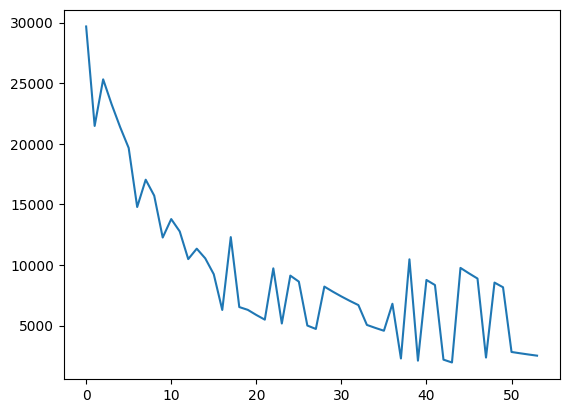

In [ ]:
# Create the untrained classifier
model = SGDClassifier(regularizer_dampening=1,
                      learning_rate=9,
                      tolerance=0.1,
                      patience=10,
                      batches=10)

# Train the classifier
model.fit(X_train_tfidf, y_train)

# Get the parameter vector
omega = model._omega

# Plot the loss curve
loss = model.loss_

import matplotlib.pyplot as plt

plt.plot(loss)
plt.show()


### SGD med learning-rate scheduler

In [ ]:
class SGDClassifierExponentialLR:
  '''
  Fancy gradient descent with mini batches and exponential learning-rate scheduler.
  '''
  def __init__(self, regularizer_dampening=0.001, verbose=True, decay_rate=0.95, initial_lr=0.01, tolerance=0.001, patience=5, batches=10):
    self.regularizer_dampening = regularizer_dampening
    self.verbose = verbose
    self.decay_rate = decay_rate # ny hyperparameter ersätter lr, dvs samma totala antal hyperparametrar
    self.initial_lr = initial_lr # startvärde för att skala ner lr från decay_rate's storleksordning första iterationerna
    self.tolerance = tolerance
    self.patience = patience
    self.batches = batches

    self.current_batch = 0

    self._omega = np.zeros(0)
    self.loss_ = []
    self.lr_ = []

  def fit(self, X, y):
    X = self._add_pseudo_iput(X)

    feature_dims = X.shape[1]

    self._omega = np.zeros(feature_dims)
    self._omega += np.random.normal(size=feature_dims)

    assert self._omega.shape[0] == feature_dims

    running_out_of_patience_in = self.patience
    best_loss = np.inf
    iteration = 0
    while running_out_of_patience_in > 0:
      iteration += 1
      current_loss = self._fit(X, y, iteration) # ett extra argument
      if self.verbose:
        print(f"Epoch {iteration}, batch {self.current_batch + 1}/{self.batches}, γ = {self.lr_[-1]:.1e}: {current_loss:.0f}")
      self.loss_.append(current_loss)
      if best_loss - current_loss > self.tolerance:
        best_loss = current_loss
        running_out_of_patience_in = self.patience
      else:
        running_out_of_patience_in -= 1
        if self.verbose:
          print(f"Patience: {running_out_of_patience_in}")
    
    return self

  def predict(self, X):
    '''Crisp predictions, unlike the prediction used in the hinge loss'''
    X = self._add_pseudo_iput(X)
    y_hat = np.sign(X @ self._omega)
    assert y_hat.shape == (X.shape[0],)
    
    return y_hat

  def score(self, X, y) -> float:
    '''
    Hinge loss with l2 regularization.
    y are the correct labels.
    Outputs a positive float.
    '''
    regularization_term = self.regularizer_dampening/2 * np.sum(np.square(self._omega))
    raw_y_hat = X @ self._omega
    hinge_loss_term = np.sum(np.maximum(0, 1 - y * raw_y_hat))
    loss = regularization_term + hinge_loss_term
    
    assert isinstance(loss, float)
    assert loss >= 0

    return loss
  
  def _fit(self, X, y, t):
    n = X.shape[0]
    batch_size = n // self.batches
    self.current_batch = np.random.randint(0, self.batches)
    start = self.current_batch * batch_size
    if self.current_batch == self.batches - 1:
      batch_size += n % self.batches
    stop = start + batch_size

    X_batch = X[start:stop]
    y_batch = y[start:stop]

    assert X_batch.shape[0] != 0 # försäkra oss om att batchen inte är tom/buggad

    self._omega -= self._ExponentialLR(t) * self._hinge_gradient(X_batch, y_batch) # <-- den nya descenten
    return self.score(X, y)

  def _hinge_gradient(self, X, y):
    assert X.shape[0] == y.shape[0]
    assert X.shape[1] == self._omega.shape[0]

    regularization_term = self.regularizer_dampening * self._omega
    gradient = regularization_term 
    for i in range(X.shape[0]):
      raw_y_hat_i = self._omega @ X[i, :]
      if y[i] * raw_y_hat_i >= 1:
        continue
      else:
        gradient -= y[i] * X[i]
    batch_size = X.shape[0]
    gradient = gradient / batch_size
    return gradient

  def _add_pseudo_iput(self, X):
    '''Add a row of pseudo-inputs'''
    n = X.shape[0]
    pseudo_input = np.ones(shape=(n, 1))
    X = np.concatenate([X, pseudo_input], axis=1)

    return X
  
  def _ExponentialLR(self, t):
    lr = self.initial_lr * (self.decay_rate ** t)  # # först tänkte jag fel och hade exp(-t*decay_rate), vilket aldrig konvergerade
    self.lr_.append(lr)

    return self.lr_[-1]  

Epoch 1, batch 8/10, γ = 3.4e+01: 2187
Epoch 2, batch 5/10, γ = 2.9e+01: 26016
Patience: 14
Epoch 3, batch 2/10, γ = 2.5e+01: 8354
Patience: 13
Epoch 4, batch 6/10, γ = 2.1e+01: 6503
Patience: 12
Epoch 5, batch 10/10, γ = 1.8e+01: 3771
Patience: 11
Epoch 6, batch 1/10, γ = 1.5e+01: 12049
Patience: 10
Epoch 7, batch 4/10, γ = 1.3e+01: 7938
Patience: 9
Epoch 8, batch 2/10, γ = 1.1e+01: 5737
Patience: 8
Epoch 9, batch 10/10, γ = 9.3e+00: 5827
Patience: 7
Epoch 10, batch 5/10, γ = 7.9e+00: 4164
Patience: 6
Epoch 11, batch 2/10, γ = 6.7e+00: 3532
Patience: 5
Epoch 12, batch 7/10, γ = 5.7e+00: 3867
Patience: 4
Epoch 13, batch 1/10, γ = 4.8e+00: 2713
Patience: 3
Epoch 14, batch 8/10, γ = 4.1e+00: 3019
Patience: 2
Epoch 15, batch 1/10, γ = 3.5e+00: 2152
Epoch 16, batch 5/10, γ = 3.0e+00: 2040
Epoch 17, batch 9/10, γ = 2.5e+00: 2094
Patience: 14
Epoch 18, batch 2/10, γ = 2.1e+00: 1699
Epoch 19, batch 8/10, γ = 1.8e+00: 1953
Patience: 14
Epoch 20, batch 5/10, γ = 1.6e+00: 1637
Epoch 21, batch 1/

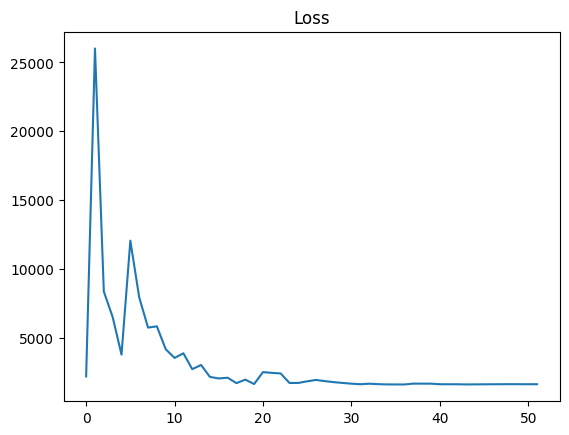

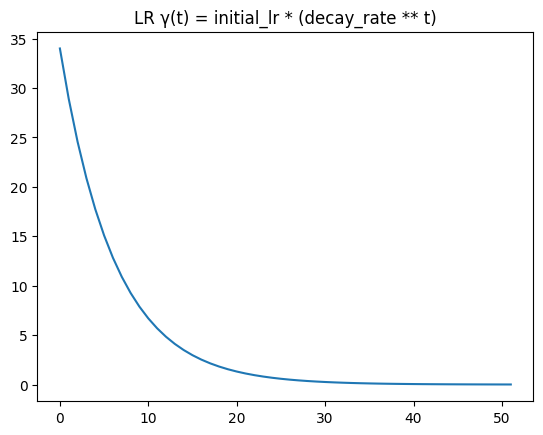

In [ ]:
# Set hyperparameters
regularizer_dampening = 5   # λ
initial_lr = 40  # Initial learning rate
decay_rate = 0.85  # Decay factor per iteration

# Create the untrained classifier
model = SGDClassifierExponentialLR(regularizer_dampening=regularizer_dampening, initial_lr=initial_lr, decay_rate=decay_rate, verbose=True, tolerance=0.05, patience=15, batches=10)

# Train the classifier
model.fit(X_train_tfidf, y_train)

omega = model._omega
loss = model.loss_
lr = model.lr_

import matplotlib.pyplot as plt

plt.title("Loss")
plt.plot(loss)
plt.show()

plt.title("LR γ(t) = initial_lr * (decay_rate ** t)")
plt.plot(lr)
plt.show()

# K-fold cross validation

Vi implementerar k-faldig korsvalidering, men först måste vi såklart ta fram bra hyperparametrar åt de två nya modellerna för att få en rättvis jämförelse, eftersom `GDClassifier` har optimerats.

### Hyperparameteroptimisering för de nya modellerna

In [ ]:
from tqdm import tqdm

def get_best_hyperparams_sgd(type="SGDClassifier", n_samples=100):
  rand_gen = np.random.default_rng()

  best_hyperparams_1 = 0
  best_hyperparams_2 = 0
  best_hyperparams_3 = 0
  best_hyperparams_4 = 0
  best_accuracy = 0

  if type == "SGDClassifier":
    print(type)
    for learning_rate, regularizer_dampening, tolerance in tqdm(zip(
        rand_gen.choice(np.logspace(0, 1, num=1000, base=10.0), n_samples),  # 1e-4 to 1e-2
        rand_gen.choice(np.logspace(-1, 1, num=1000, base=10.0), n_samples),  # 1e-5 to 1e-3
        rand_gen.choice(np.logspace(-3, -1, num=1000, base=10.0), n_samples)), total=n_samples):  # tolerance

      model = SGDClassifier(regularizer_dampening=regularizer_dampening, learning_rate=learning_rate, batches=10, tolerance=tolerance, patience=10, verbose=False)
      model.fit(X_train_tfidf, y_train)
      training_accuracy = np.sum(model.predict(X_train_tfidf)==y_train)/len(y_train)

      if training_accuracy > best_accuracy:
        best_accuracy = training_accuracy
        best_hyperparams_1 = learning_rate
        best_hyperparams_2 = regularizer_dampening
        best_hyperparams_3 = tolerance
        print(f"New best: lr={learning_rate:.2e}, λ={regularizer_dampening:.2e}, acc={best_accuracy*100:.2f}%")
    
    return best_hyperparams_1, best_hyperparams_2, best_hyperparams_3, best_accuracy
  
  elif type == "SGDClassifierExponentialLR":
    print(type)
    for initial_lr, decay_rate, regularizer_dampening, tolerance in tqdm(zip(
        rand_gen.choice(np.logspace(0, 2, num=1000, base=10.0), n_samples),  # initial_lr (1e-3 to 1e-1)
        rand_gen.choice(np.linspace(0.85, 0.99, num=1000), n_samples),  # decay_rate
        rand_gen.choice(np.logspace(-2, 0, num=1000, base=10.0), n_samples),  # lambda
        rand_gen.choice(np.logspace(-3, -1, num=1000, base=10.0), n_samples)), total=n_samples):  # tolerance

      model = SGDClassifierExponentialLR(regularizer_dampening=regularizer_dampening, batches=10, initial_lr=initial_lr, decay_rate=decay_rate, tolerance=tolerance, patience=10, verbose=False)
      model.fit(X_train_tfidf, y_train)
      training_accuracy = np.sum(model.predict(X_train_tfidf)==y_train)/len(y_train)

      if training_accuracy > best_accuracy:
        best_accuracy = training_accuracy
        best_hyperparams_1 = initial_lr
        best_hyperparams_2 = decay_rate
        best_hyperparams_3 = regularizer_dampening
        best_hyperparams_4 = tolerance
        print(f"New best (acc={best_accuracy*100:.2f}%): initial_lr={initial_lr:.2e}, decay={decay_rate:.4f}, λ={regularizer_dampening:.2e}, tolerance={tolerance:.2e}")

  return best_hyperparams_1, best_hyperparams_2, best_hyperparams_3, best_hyperparams_4, best_accuracy

In [ ]:
n_samples = 100


# For SGDClassifierExponentialLR: returns (initial_lr, decay_rate, regularizer_dampening, tolerance, accuracy)
initial_lr_sgde, decay_rate_sgde, best_regularizer_dampening_sgde, best_tolerance_sgde, best_accuracy_sgde = get_best_hyperparams_sgd(type="SGDClassifierExponentialLR", n_samples=n_samples)

# For SGDClassifier: returns (learning_rate, regularizer_dampening, tolerance, accuracy)
best_learning_rate_sgd, best_regularizer_dampening_sgd, best_tolerance_sgd, best_accuracy_sgd = get_best_hyperparams_sgd(type="SGDClassifier", n_samples=n_samples)


print(f"Best hyperparameters for SGDClassifier ({best_accuracy_sgd:.4f}): learning rate = {best_learning_rate_sgd:.6f}, regularizer dampening = {best_regularizer_dampening_sgd:.6f}, tolerance = {best_tolerance_sgd:.6f}")
print(f"Best hyperparameters for SGDClassifierExponentialLR ({best_accuracy_sgde:.4f}): initial_lr = {initial_lr_sgde:.6f}, decay rate = {decay_rate_sgde:.6f}, regularizer dampening = {best_regularizer_dampening_sgde:.6f}, tolerance = {best_tolerance_sgde:.6f}")

SGDClassifierExponentialLR


  1%|          | 1/100 [00:00<01:12,  1.36it/s]

New best (acc=54.44%): initial_lr=1.61e+00, decay=0.8607, λ=4.74e-01, tolerance=3.69e-02


  3%|▎         | 3/100 [00:03<02:02,  1.26s/it]

New best (acc=55.56%): initial_lr=9.62e+00, decay=0.8874, λ=1.36e-01, tolerance=1.21e-03


...

New best: lr=1.68e+00, λ=8.34e-01, acc=55.56%


 27%|██▋       | 27/100 [00:53<02:54,  2.39s/it]

New best: lr=1.24e+00, λ=6.41e-01, acc=55.78%


100%|██████████| 100/100 [02:57<00:00,  1.78s/it]

Best hyperparameters for SGDClassifier (0.5578): learning rate = 1.239062, regularizer dampening = 0.640924, tolerance = 0.043615
Best hyperparameters for SGDClassifierExponentialLR (0.5611): initial_lr = 44.632339, decay rate = 0.943333, regularizer dampening = 0.056072, tolerance = 0.005633


### Slutkläm: korsvalideringen

Med 10 folds tar testen ungefär en halvtimme. Sorgligt nog lyckades jag inte få bra test-resultat från någon av modellerna och har trots mycket meckande inte identifierat någon tydlig bugg eller enskild orsak, trots att i alla fall den första modellen lyckades få 99% på träningen (det vill säga, den blev övertränad på något vis).

In [ ]:
import time

def model_test(k, X_train, X_test, regularizer_dampening, model_type="GD", learning_rate=0.00001, batches=10, initial_lr=0.01, decay_rate=0.95, tolerance=0.01, patience=10, verbose=False):
    # Fixed: use explicit model_type parameter instead of broken conditional logic
    if model_type == "GD":
        print("Testing GDClassifier...")
        model = GDClassifier(regularizer_dampening=regularizer_dampening, learning_rate=learning_rate, tolerance=tolerance, patience=patience, verbose=verbose)
    elif model_type == "SGD":
        print("Testing SGDClassifier...")
        model = SGDClassifier(regularizer_dampening=regularizer_dampening, learning_rate=learning_rate, batches=batches, tolerance=tolerance, patience=patience, verbose=verbose)
    elif model_type == "SGDExponential":
        print("Testing SGDClassifierExponentialLR...")
        model = SGDClassifierExponentialLR(regularizer_dampening=regularizer_dampening, batches=batches, initial_lr=initial_lr, decay_rate=decay_rate, tolerance=tolerance, patience=patience, verbose=verbose)
    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    # Train
    print("Training...")
    model.fit(X_train, y_train)

    # Test
    t_0 = time.time()
    test_accuracy = np.sum(model.predict(X_test)==y_test)/len(y_test)
    t_1 = time.time()

    duration = t_1 - t_0
    print(f"Test set accuracy: {test_accuracy*100:.1f}%, Time taken: {duration:.2f} seconds")

    loss = model.loss_
    lr = model.lr_ if hasattr(model, 'lr_') else []

    import matplotlib.pyplot as plt

    plt.title(f"Loss {model_type} (fold {k})")
    plt.plot(loss)
    plt.savefig(f"plts/{model_type}_loss_fold_{k}")
    plt.show()
    
    if len(lr) > 0:
        plt.title(f"Learning Rate Schedule {model_type} (fold {k})")
        plt.plot(lr)
        plt.savefig(f"plts/{model_type}_lr_fold_{k}")
        plt.show()

    return test_accuracy, duration

  0%|          | 0/10 [00:00<?, ?it/s]

Fold 1/10: Fitting and embedding BoW...


100%|██████████| 200/200 [00:00<00:00, 590.56it/s]


Fold 1/10: Fitting and embedding TFIDF...


100%|██████████| 200/200 [00:00<00:00, 310.47it/s]


Testing GDClassifier...
Training...
1: 15886
2: 15281
3: 14761
4: 14301
5: 13921
6: 13602
7: 13337
8: 13109
9: 12919
10: 12762
11: 12638
12: 12535
13: 12448
14: 12375
15: 12318
16: 12270
17: 12227
18: 12190
19: 12160
20: 12133
21: 12110
22: 12091
23: 12075
24: 12061
25: 12048
26: 12036
27: 12025
28: 12013
29: 12003
30: 11992
31: 11982
32: 11973
33: 11963
34: 11954
35: 11945
36: 11936
37: 11928
38: 11919
39: 11911
40: 11902
41: 11893
42: 11885
43: 11876
44: 11868
45: 11859
46: 11851
47: 11842
48: 11834
49: 11826
50: 11817
51: 11809
52: 11800
53: 11792
54: 11783
55: 11775
56: 11766
57: 11758
58: 11750
59: 11741
60: 11733
61: 11724
62: 11716
63: 11707
64: 11699
65: 11691
66: 11682
67: 11674
68: 11666
69: 11657
70: 11649
71: 11641
72: 11633
73: 11624
74: 11616
75: 11608
76: 11599
77: 11591
78: 11583
79: 11575
80: 11566
81: 11558
82: 11550
83: 11542
84: 11534
85: 11526
86: 11517
87: 11509
88: 11501
89: 11493
90: 11485
91: 11477
92: 11468
93: 11460
94: 11452
95: 11444
96: 11436
97: 11428
98:

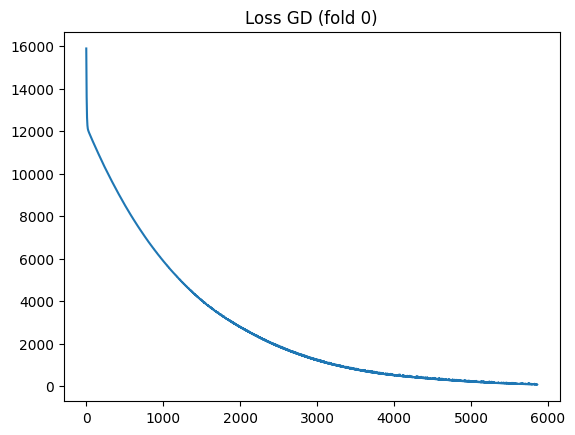

Testing SGDClassifier...
Training...
1 (batch 6/10): 67303
2 (batch 3/10): 65111
3 (batch 6/10): 62604
4 (batch 3/10): 60590
5 (batch 2/10): 58987
6 (batch 3/10): 56901
7 (batch 1/10): 54896
8 (batch 7/10): 52475
9 (batch 9/10): 50447
10 (batch 1/10): 48857
11 (batch 9/10): 46952
12 (batch 6/10): 45715
13 (batch 7/10): 44102
14 (batch 10/10): 42547
15 (batch 3/10): 40800
16 (batch 4/10): 39613
17 (batch 6/10): 38005
18 (batch 9/10): 36938
19 (batch 8/10): 35643
20 (batch 7/10): 34396
21 (batch 4/10): 33020
22 (batch 8/10): 32051
23 (batch 10/10): 30933
24 (batch 6/10): 29855
25 (batch 1/10): 28725
26 (batch 1/10): 28001
27 (batch 9/10): 26794
28 (batch 3/10): 26135
29 (batch 8/10): 25001
30 (batch 8/10): 24275
31 (batch 8/10): 23440
32 (batch 9/10): 22634
33 (batch 8/10): 21858
34 (batch 7/10): 21110
35 (batch 5/10): 20261
36 (batch 9/10): 20218
37 (batch 3/10): 18940
38 (batch 9/10): 18899
39 (batch 5/10): 17852
40 (batch 8/10): 17249
41 (batch 7/10): 16668
42 (batch 8/10): 16108
43 (

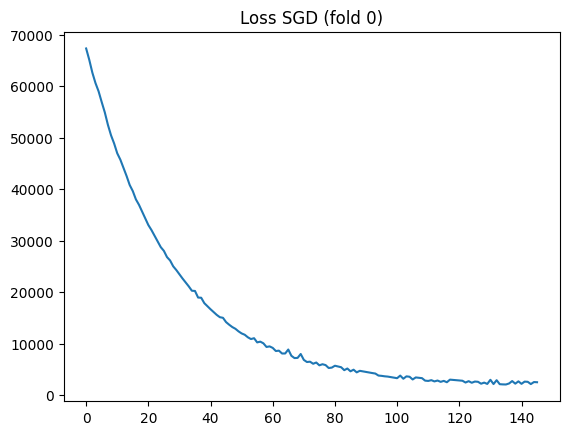

Testing SGDClassifierExponentialLR...
Training...
Epoch 1, batch 9/10, γ = 1.9e+00: 1836
Epoch 2, batch 2/10, γ = 1.8e+00: 2942
Patience: 9
Epoch 3, batch 3/10, γ = 1.8e+00: 2942
Patience: 8
Epoch 4, batch 9/10, γ = 1.7e+00: 1865
Patience: 7
Epoch 5, batch 10/10, γ = 1.6e+00: 1926
Patience: 6
Epoch 6, batch 7/10, γ = 1.6e+00: 1926
Patience: 5
Epoch 7, batch 7/10, γ = 1.5e+00: 1926
Patience: 4
Epoch 8, batch 8/10, γ = 1.4e+00: 1926
Patience: 3
Epoch 9, batch 3/10, γ = 1.4e+00: 1815
Epoch 10, batch 10/10, γ = 1.3e+00: 1882
Patience: 9
Epoch 11, batch 3/10, γ = 1.3e+00: 1804
Epoch 12, batch 7/10, γ = 1.2e+00: 1841
Patience: 9
Epoch 13, batch 7/10, γ = 1.2e+00: 1851
Patience: 8
Epoch 14, batch 5/10, γ = 1.1e+00: 1664
Epoch 15, batch 5/10, γ = 1.1e+00: 1657
Epoch 16, batch 4/10, γ = 1.0e+00: 1848
Patience: 9
Epoch 17, batch 6/10, γ = 9.8e-01: 1660
Patience: 8
Epoch 18, batch 6/10, γ = 9.4e-01: 2155
Patience: 7
Epoch 19, batch 9/10, γ = 9.0e-01: 2155
Patience: 6
Epoch 20, batch 7/10, γ = 8.6

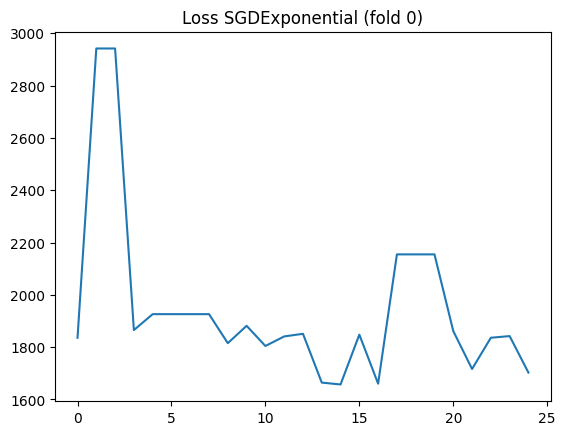

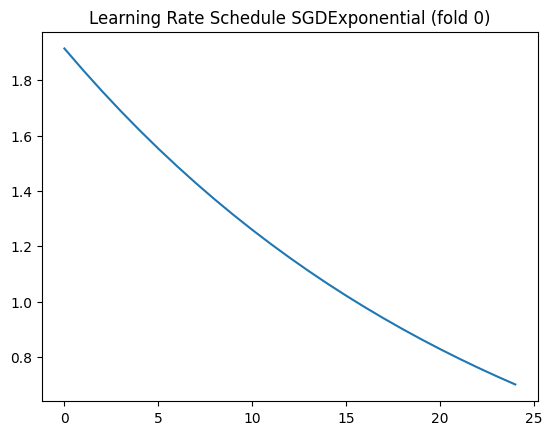

 10%|█         | 1/10 [04:15<38:17, 255.26s/it]

Fold 2/10: Fitting and embedding BoW...


100%|██████████| 200/200 [00:00<00:00, 592.42it/s]


Fold 2/10: Fitting and embedding TFIDF...


100%|██████████| 200/200 [00:00<00:00, 370.74it/s]


Testing GDClassifier...
Training...
1: 12504
2: 12440
3: 12384
4: 12338
5: 12300
6: 12269
7: 12243
8: 12221
9: 12202
10: 12185
11: 12169
12: 12155
13: 12142
14: 12130
15: 12118
16: 12107
17: 12098
18: 12088
19: 12079
20: 12071
21: 12062
22: 12053
23: 12045
24: 12036
25: 12028
26: 12020
27: 12012
28: 12004
29: 11995
30: 11987
31: 11979
32: 11971
33: 11963
34: 11955
35: 11947
36: 11939
37: 11931
38: 11923
39: 11915
40: 11907
41: 11899
42: 11891
43: 11883
44: 11876
45: 11868
46: 11860
47: 11852
48: 11844
49: 11836
50: 11828
51: 11820
52: 11812
53: 11805
54: 11797
55: 11789
56: 11781
57: 11773
58: 11766
59: 11758
60: 11750
61: 11742
62: 11735
63: 11727
64: 11719
65: 11711
66: 11704
67: 11696
68: 11688
69: 11680
70: 11673
71: 11665
72: 11657
73: 11649
74: 11642
75: 11634
76: 11626
77: 11618
78: 11611
79: 11603
80: 11595
81: 11588
82: 11580
83: 11572
84: 11565
85: 11557
86: 11549
87: 11542
88: 11534
89: 11526
90: 11519
91: 11511
92: 11504
93: 11496
94: 11488
95: 11481
96: 11473
97: 11466
98:

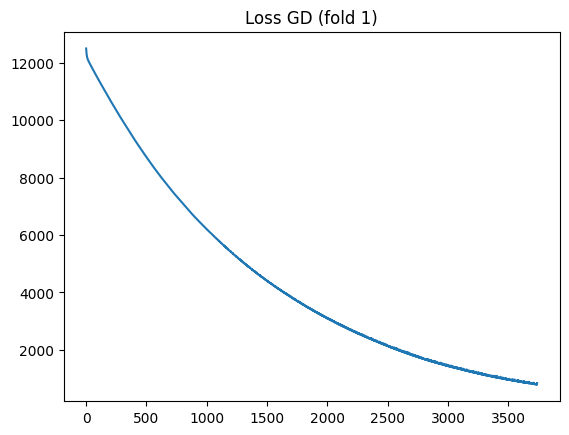

Testing SGDClassifier...
Training...
1 (batch 10/10): 69253
2 (batch 1/10): 66535
3 (batch 9/10): 64418
4 (batch 7/10): 62128
5 (batch 8/10): 59920
6 (batch 3/10): 57614
7 (batch 1/10): 55830
8 (batch 5/10): 53797
9 (batch 3/10): 52774
10 (batch 5/10): 50282
11 (batch 4/10): 48681
12 (batch 6/10): 46533
13 (batch 9/10): 44763
14 (batch 1/10): 43339
15 (batch 8/10): 41671
16 (batch 6/10): 40444
17 (batch 10/10): 39020
18 (batch 1/10): 37562
19 (batch 2/10): 36527
20 (batch 5/10): 35150
21 (batch 2/10): 34761
22 (batch 9/10): 32765
23 (batch 6/10): 31408
24 (batch 2/10): 30559
25 (batch 10/10): 29282
26 (batch 1/10): 28511
27 (batch 6/10): 27308
28 (batch 3/10): 26609
29 (batch 2/10): 26500
30 (batch 9/10): 24834
31 (batch 6/10): 23766
32 (batch 10/10): 23549
33 (batch 4/10): 22195
34 (batch 7/10): 21990
35 (batch 8/10): 21244
36 (batch 7/10): 20524
37 (batch 9/10): 19831
38 (batch 10/10): 19162
39 (batch 9/10): 18517
40 (batch 3/10): 17541
41 (batch 8/10): 17312
42 (batch 1/10): 16417
4

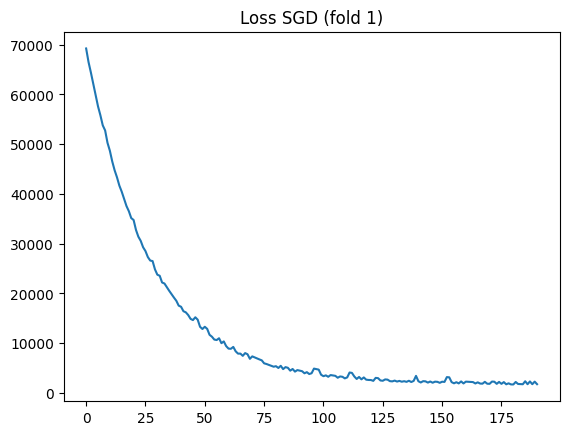

Testing SGDClassifierExponentialLR...
Training...
Epoch 1, batch 10/10, γ = 1.9e+00: 1896
Epoch 2, batch 8/10, γ = 1.8e+00: 1904
Patience: 9
Epoch 3, batch 7/10, γ = 1.8e+00: 1904
Patience: 8
Epoch 4, batch 4/10, γ = 1.7e+00: 1884
Epoch 5, batch 6/10, γ = 1.6e+00: 1849
Epoch 6, batch 2/10, γ = 1.6e+00: 1871
Patience: 9
Epoch 7, batch 2/10, γ = 1.5e+00: 2772
Patience: 8
Epoch 8, batch 5/10, γ = 1.4e+00: 2038
Patience: 7
Epoch 9, batch 4/10, γ = 1.4e+00: 2740
Patience: 6
Epoch 10, batch 8/10, γ = 1.3e+00: 1900
Patience: 5
Epoch 11, batch 9/10, γ = 1.3e+00: 1655
Epoch 12, batch 7/10, γ = 1.2e+00: 2368
Patience: 9
Epoch 13, batch 2/10, γ = 1.2e+00: 1664
Patience: 8
Epoch 14, batch 6/10, γ = 1.1e+00: 2315
Patience: 7
Epoch 15, batch 5/10, γ = 1.1e+00: 1937
Patience: 6
Epoch 16, batch 10/10, γ = 1.0e+00: 1937
Patience: 5
Epoch 17, batch 1/10, γ = 9.8e-01: 1734
Patience: 4
Epoch 18, batch 10/10, γ = 9.4e-01: 1905
Patience: 3
Epoch 19, batch 7/10, γ = 9.0e-01: 1905
Patience: 2
Epoch 20, batch 

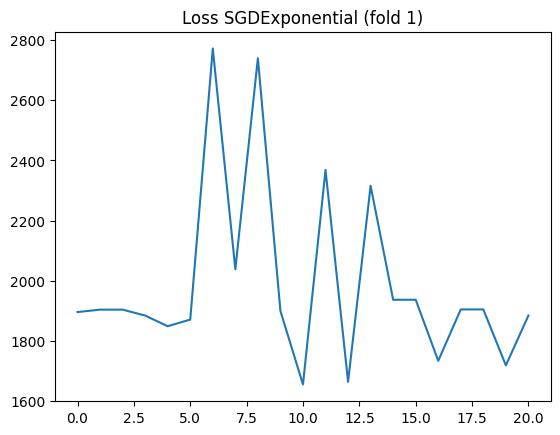

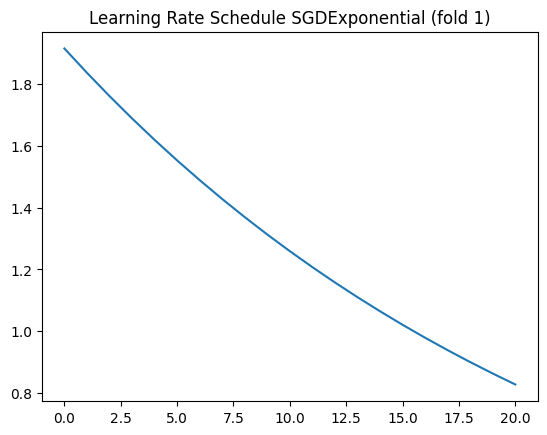

 20%|██        | 2/10 [07:04<27:18, 204.84s/it]

Fold 3/10: Fitting and embedding BoW...


100%|██████████| 200/200 [00:00<00:00, 594.11it/s]


Fold 3/10: Fitting and embedding TFIDF...


100%|██████████| 200/200 [00:00<00:00, 368.35it/s]


Testing GDClassifier...
Training...
1: 15587
2: 15004
3: 14514
4: 14121
5: 13795
6: 13537
7: 13318
8: 13129
9: 12962
10: 12820
11: 12703
12: 12599
13: 12515
14: 12446
15: 12392
16: 12347
17: 12309
18: 12278
19: 12253
20: 12231
21: 12211
22: 12194
23: 12178
24: 12164
25: 12151
26: 12139
27: 12127
28: 12116
29: 12106
30: 12096
31: 12086
32: 12077
33: 12068
34: 12059
35: 12050
36: 12041
37: 12032
38: 12024
39: 12015
40: 12007
41: 11998
42: 11990
43: 11981
44: 11973
45: 11964
46: 11956
47: 11947
48: 11939
49: 11930
50: 11922
51: 11913
52: 11905
53: 11896
54: 11888
55: 11880
56: 11871
57: 11863
58: 11854
59: 11846
60: 11838
61: 11829
62: 11821
63: 11812
64: 11804
65: 11796
66: 11787
67: 11779
68: 11771
69: 11762
70: 11754
71: 11746
72: 11737
73: 11729
74: 11721
75: 11712
76: 11704
77: 11696
78: 11688
79: 11679
80: 11671
81: 11663
82: 11655
83: 11646
84: 11638
85: 11630
86: 11622
87: 11613
88: 11605
89: 11597
90: 11589
91: 11581
92: 11572
93: 11564
94: 11556
95: 11548
96: 11540
97: 11532
98:

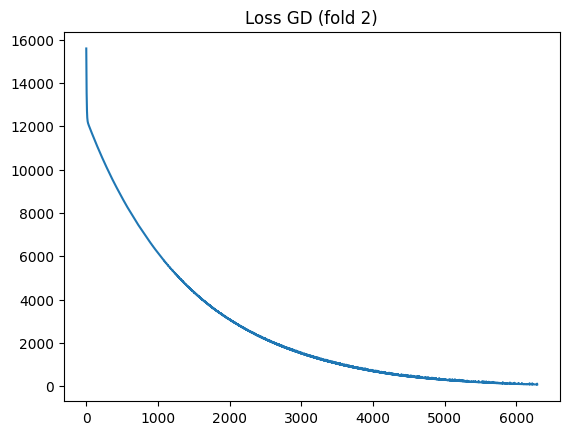

Testing SGDClassifier...
Training...
1 (batch 10/10): 68567
2 (batch 9/10): 66771
3 (batch 8/10): 64396
4 (batch 4/10): 61558
5 (batch 7/10): 59916
6 (batch 6/10): 57789
7 (batch 7/10): 55739
8 (batch 1/10): 53321
9 (batch 10/10): 51875
10 (batch 4/10): 49638
11 (batch 4/10): 48127
12 (batch 2/10): 47338
13 (batch 2/10): 45683
14 (batch 6/10): 43243
15 (batch 9/10): 41503
16 (batch 3/10): 40288
17 (batch 3/10): 39718
18 (batch 10/10): 37534
19 (batch 3/10): 37033
20 (batch 6/10): 34978
21 (batch 8/10): 33540
22 (batch 6/10): 32963
23 (batch 8/10): 31817
24 (batch 2/10): 30199
25 (batch 4/10): 29395
26 (batch 9/10): 28160
27 (batch 7/10): 27702
28 (batch 8/10): 26747
29 (batch 5/10): 25414
30 (batch 7/10): 24580
31 (batch 6/10): 23736
32 (batch 5/10): 22865
33 (batch 1/10): 22327
34 (batch 7/10): 21350
35 (batch 1/10): 20867
36 (batch 7/10): 19943
37 (batch 10/10): 19840
38 (batch 6/10): 19172
39 (batch 7/10): 18528
40 (batch 4/10): 17445
41 (batch 7/10): 17326
42 (batch 1/10): 16327
43

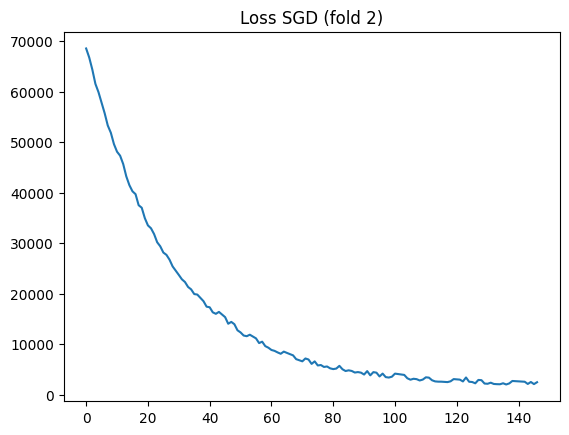

Testing SGDClassifierExponentialLR...
Training...
Epoch 1, batch 8/10, γ = 1.9e+00: 2508
Epoch 2, batch 6/10, γ = 1.8e+00: 2508
Epoch 3, batch 8/10, γ = 1.8e+00: 2508
Epoch 4, batch 1/10, γ = 1.7e+00: 1723
Epoch 5, batch 2/10, γ = 1.6e+00: 2208
Patience: 9
Epoch 6, batch 4/10, γ = 1.6e+00: 2342
Patience: 8
Epoch 7, batch 4/10, γ = 1.5e+00: 2359
Patience: 7
Epoch 8, batch 10/10, γ = 1.4e+00: 1792
Patience: 6
Epoch 9, batch 4/10, γ = 1.4e+00: 2301
Patience: 5
Epoch 10, batch 8/10, γ = 1.3e+00: 1803
Patience: 4
Epoch 11, batch 6/10, γ = 1.3e+00: 1844
Patience: 3
Epoch 12, batch 10/10, γ = 1.2e+00: 1865
Patience: 2
Epoch 13, batch 8/10, γ = 1.2e+00: 1875
Patience: 1
Epoch 14, batch 6/10, γ = 1.1e+00: 1885
Patience: 0
Test set accuracy: 0.0%, Time taken: 0.01 seconds


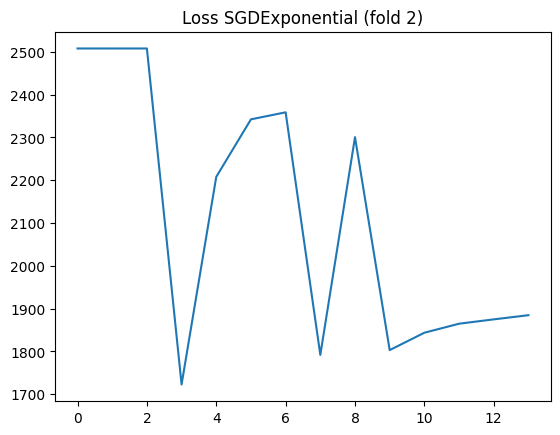

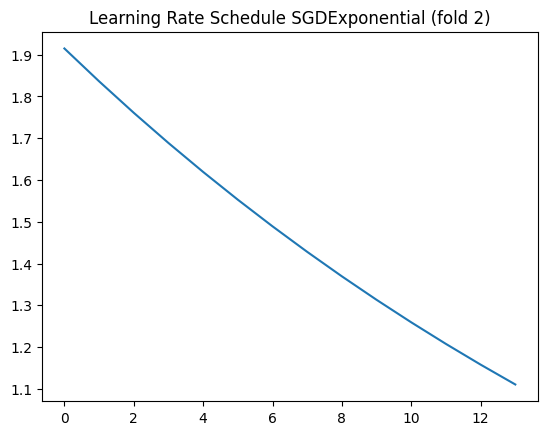

 30%|███       | 3/10 [11:17<26:25, 226.56s/it]

Fold 4/10: Fitting and embedding BoW...


100%|██████████| 200/200 [00:00<00:00, 588.27it/s]


Fold 4/10: Fitting and embedding TFIDF...


100%|██████████| 200/200 [00:00<00:00, 371.64it/s]


Testing GDClassifier...
Training...
1: 17245
2: 16650
3: 16117
4: 15657
5: 15255
6: 14896
7: 14592
8: 14332
9: 14113
10: 13925
11: 13764
12: 13628
13: 13517
14: 13424
15: 13348
16: 13286
17: 13237
18: 13192
19: 13150
20: 13114
21: 13082
22: 13055
23: 13033
24: 13013
25: 12995
26: 12978
27: 12961
28: 12947
29: 12933
30: 12919
31: 12906
32: 12893
33: 12882
34: 12871
35: 12860
36: 12850
37: 12840
38: 12830
39: 12821
40: 12811
41: 12802
42: 12793
43: 12784
44: 12775
45: 12766
46: 12757
47: 12749
48: 12740
49: 12731
50: 12722
51: 12714
52: 12705
53: 12696
54: 12687
55: 12679
56: 12670
57: 12661
58: 12653
59: 12644
60: 12635
61: 12627
62: 12618
63: 12609
64: 12601
65: 12592
66: 12583
67: 12575
68: 12566
69: 12557
70: 12549
71: 12540
72: 12532
73: 12523
74: 12514
75: 12506
76: 12497
77: 12489
78: 12480
79: 12471
80: 12463
81: 12454
82: 12446
83: 12437
84: 12428
85: 12420
86: 12411
87: 12403
88: 12394
89: 12386
90: 12377
91: 12369
92: 12360
93: 12351
94: 12343
95: 12334
96: 12326
97: 12317
98:

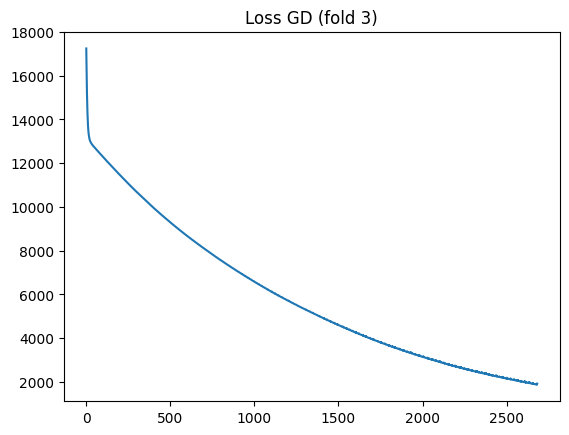

Testing SGDClassifier...
Training...
1 (batch 10/10): 68636
2 (batch 3/10): 65643
3 (batch 6/10): 63843
4 (batch 5/10): 61162
5 (batch 10/10): 59041
6 (batch 5/10): 56799
7 (batch 6/10): 55420
8 (batch 7/10): 53458
9 (batch 8/10): 51567
10 (batch 9/10): 49744
11 (batch 5/10): 47574
12 (batch 7/10): 45909
13 (batch 4/10): 44329
14 (batch 2/10): 43130
15 (batch 8/10): 41284
16 (batch 10/10): 39819
17 (batch 2/10): 38464
18 (batch 5/10): 37103
19 (batch 2/10): 36087
20 (batch 4/10): 35238
21 (batch 10/10): 33460
22 (batch 1/10): 32862
23 (batch 10/10): 31193
24 (batch 6/10): 29909
25 (batch 10/10): 29501
26 (batch 9/10): 28482
27 (batch 8/10): 27500
28 (batch 6/10): 26552
29 (batch 9/10): 25639
30 (batch 6/10): 24759
31 (batch 6/10): 23910
32 (batch 2/10): 22735
33 (batch 2/10): 22204
34 (batch 3/10): 22412
Patience: 9
35 (batch 5/10): 21019
36 (batch 6/10): 19927
37 (batch 6/10): 19171
38 (batch 6/10): 18549
39 (batch 3/10): 18019
40 (batch 7/10): 17329
41 (batch 5/10): 16730
42 (batch 3

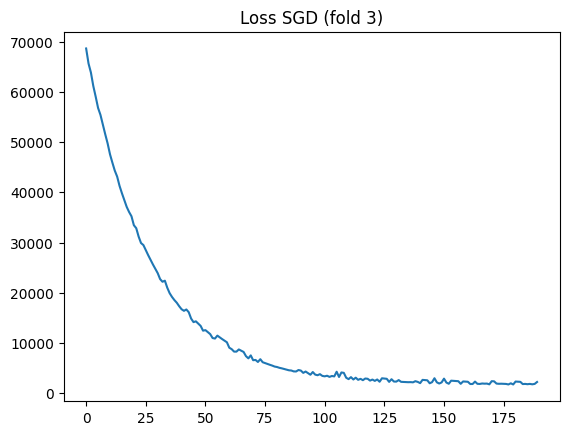

Testing SGDClassifierExponentialLR...
Training...
Epoch 1, batch 3/10, γ = 1.9e+00: 2714
Epoch 2, batch 7/10, γ = 1.8e+00: 1787
Epoch 3, batch 10/10, γ = 1.8e+00: 2337
Patience: 9
Epoch 4, batch 3/10, γ = 1.7e+00: 1773
Epoch 5, batch 3/10, γ = 1.6e+00: 2425
Patience: 9
Epoch 6, batch 9/10, γ = 1.6e+00: 1786
Patience: 8
Epoch 7, batch 10/10, γ = 1.5e+00: 2124
Patience: 7
Epoch 8, batch 9/10, γ = 1.4e+00: 2124
Patience: 6
Epoch 9, batch 5/10, γ = 1.4e+00: 1676
Epoch 10, batch 5/10, γ = 1.3e+00: 1663
Epoch 11, batch 3/10, γ = 1.3e+00: 1911
Patience: 9
Epoch 12, batch 4/10, γ = 1.2e+00: 2706
Patience: 8
Epoch 13, batch 9/10, γ = 1.2e+00: 1921
Patience: 7
Epoch 14, batch 7/10, γ = 1.1e+00: 1700
Patience: 6
Epoch 15, batch 4/10, γ = 1.1e+00: 1912
Patience: 5
Epoch 16, batch 3/10, γ = 1.0e+00: 2524
Patience: 4
Epoch 17, batch 8/10, γ = 9.8e-01: 1921
Patience: 3
Epoch 18, batch 9/10, γ = 9.4e-01: 1733
Patience: 2
Epoch 19, batch 4/10, γ = 9.0e-01: 1913
Patience: 1
Epoch 20, batch 10/10, γ = 8.

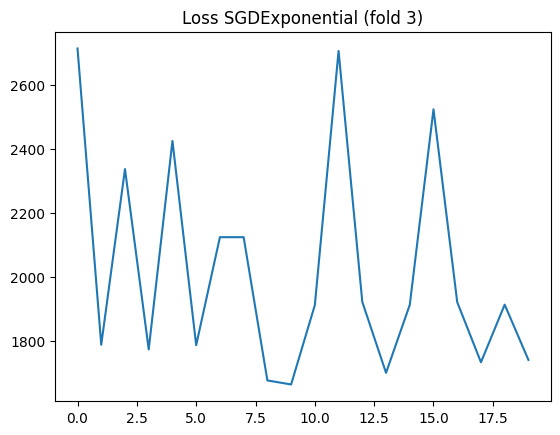

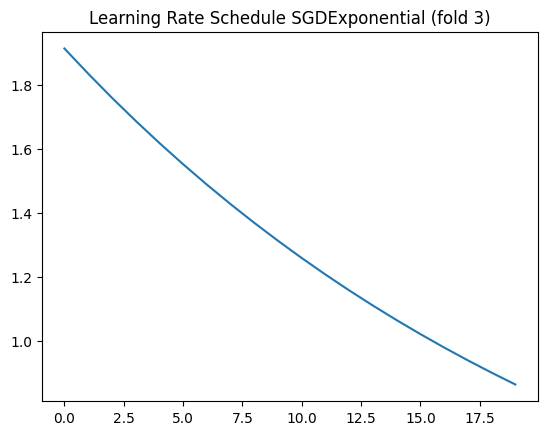

 40%|████      | 4/10 [13:30<18:57, 189.63s/it]

Fold 5/10: Fitting and embedding BoW...


100%|██████████| 200/200 [00:00<00:00, 570.68it/s]


Fold 5/10: Fitting and embedding TFIDF...


100%|██████████| 200/200 [00:00<00:00, 367.82it/s]


Testing GDClassifier...
Training...
1: 12411
2: 12244
3: 12111
4: 12004
5: 11911
6: 11838
7: 11779
8: 11731
9: 11690
10: 11658
11: 11633
12: 11612
13: 11594
14: 11576
15: 11560
16: 11545
17: 11532
18: 11521
19: 11510
20: 11499
21: 11489
22: 11480
23: 11471
24: 11462
25: 11453
26: 11444
27: 11436
28: 11427
29: 11418
30: 11410
31: 11402
32: 11393
33: 11385
34: 11377
35: 11368
36: 11360
37: 11352
38: 11343
39: 11335
40: 11327
41: 11319
42: 11311
43: 11302
44: 11294
45: 11286
46: 11278
47: 11270
48: 11262
49: 11253
50: 11245
51: 11237
52: 11229
53: 11221
54: 11213
55: 11205
56: 11197
57: 11189
58: 11181
59: 11173
60: 11165
61: 11157
62: 11149
63: 11141
64: 11133
65: 11125
66: 11117
67: 11109
68: 11101
69: 11093
70: 11085
71: 11077
72: 11070
73: 11062
74: 11054
75: 11046
76: 11038
77: 11030
78: 11022
79: 11014
80: 11006
81: 10998
82: 10990
83: 10982
84: 10974
85: 10966
86: 10958
87: 10951
88: 10943
89: 10935
90: 10927
91: 10919
92: 10911
93: 10903
94: 10895
95: 10887
96: 10880
97: 10872
98:

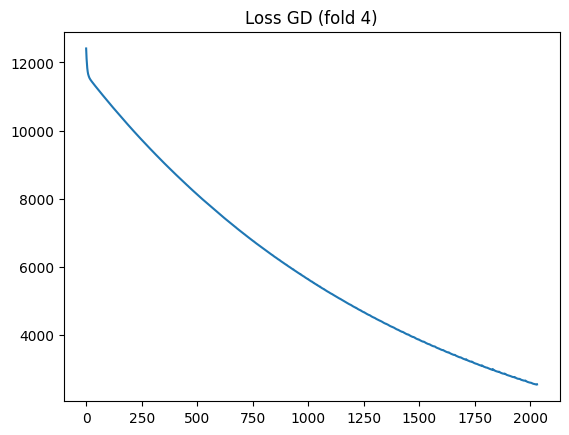

Testing SGDClassifier...
Training...
1 (batch 9/10): 68122
2 (batch 3/10): 65959
3 (batch 3/10): 64358
4 (batch 10/10): 61285
5 (batch 7/10): 58890
6 (batch 2/10): 57040
7 (batch 4/10): 55821
8 (batch 3/10): 53855
9 (batch 9/10): 51219
10 (batch 3/10): 50155
11 (batch 10/10): 47685
12 (batch 2/10): 46719
13 (batch 9/10): 44403
14 (batch 3/10): 43527
15 (batch 6/10): 41355
16 (batch 7/10): 39686
17 (batch 4/10): 38533
18 (batch 5/10): 37171
19 (batch 2/10): 36429
20 (batch 8/10): 34639
21 (batch 3/10): 33966
22 (batch 6/10): 32288
23 (batch 2/10): 31678
24 (batch 7/10): 30105
25 (batch 10/10): 28887
26 (batch 7/10): 28268
27 (batch 8/10): 27289
28 (batch 8/10): 26346
29 (batch 5/10): 25113
30 (batch 2/10): 24486
31 (batch 3/10): 24229
32 (batch 5/10): 22965
33 (batch 3/10): 23147
Patience: 9
34 (batch 8/10): 21452
35 (batch 10/10): 20507
36 (batch 9/10): 20222
37 (batch 2/10): 19170
38 (batch 6/10): 18896
39 (batch 10/10): 18260
40 (batch 3/10): 17345
41 (batch 9/10): 17073
42 (batch 9/

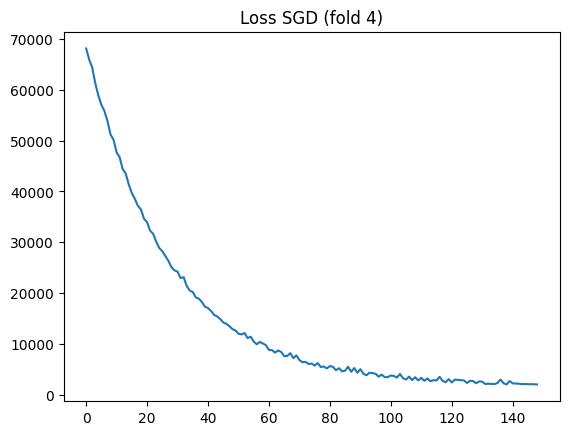

Testing SGDClassifierExponentialLR...
Training...
Epoch 1, batch 5/10, γ = 1.9e+00: 1706
Epoch 2, batch 9/10, γ = 1.8e+00: 2746
Patience: 9
Epoch 3, batch 10/10, γ = 1.8e+00: 2746
Patience: 8
Epoch 4, batch 4/10, γ = 1.7e+00: 1684
Epoch 5, batch 3/10, γ = 1.6e+00: 2019
Patience: 9
Epoch 6, batch 10/10, γ = 1.6e+00: 1697
Patience: 8
Epoch 7, batch 4/10, γ = 1.5e+00: 1999
Patience: 7
Epoch 8, batch 9/10, γ = 1.4e+00: 1708
Patience: 6
Epoch 9, batch 3/10, γ = 1.4e+00: 1984
Patience: 5
Epoch 10, batch 2/10, γ = 1.3e+00: 3058
Patience: 4
Epoch 11, batch 9/10, γ = 1.3e+00: 1983
Patience: 3
Epoch 12, batch 6/10, γ = 1.2e+00: 1739
Patience: 2
Epoch 13, batch 4/10, γ = 1.2e+00: 1972
Patience: 1
Epoch 14, batch 5/10, γ = 1.1e+00: 1944
Patience: 0
Test set accuracy: 100.0%, Time taken: 0.01 seconds


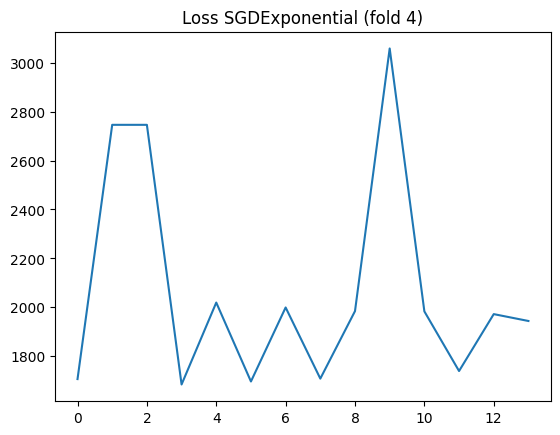

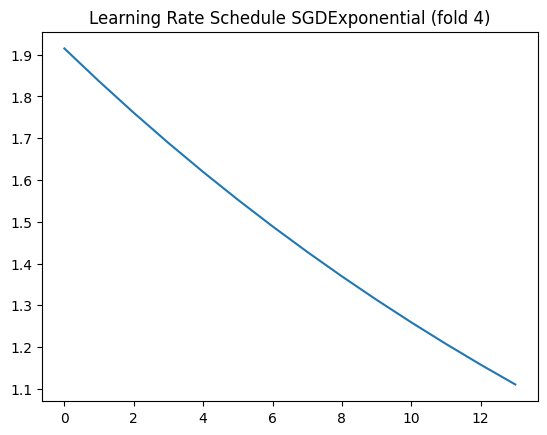

 50%|█████     | 5/10 [15:16<13:17, 159.43s/it]

Fold 6/10: Fitting and embedding BoW...


100%|██████████| 200/200 [00:00<00:00, 560.78it/s]


Fold 6/10: Fitting and embedding TFIDF...


100%|██████████| 200/200 [00:00<00:00, 369.77it/s]


Testing GDClassifier...
Training...
1: 16390
2: 15585
3: 14916
4: 14359
5: 13897
6: 13542
7: 13269
8: 13036
9: 12849
10: 12703
11: 12581
12: 12474
13: 12379
14: 12298
15: 12230
16: 12176
17: 12132
18: 12094
19: 12062
20: 12035
21: 12012
22: 11992
23: 11976
24: 11961
25: 11948
26: 11936
27: 11924
28: 11913
29: 11903
30: 11894
31: 11885
32: 11876
33: 11867
34: 11859
35: 11850
36: 11842
37: 11833
38: 11825
39: 11817
40: 11809
41: 11801
42: 11793
43: 11784
44: 11776
45: 11768
46: 11760
47: 11752
48: 11744
49: 11735
50: 11727
51: 11719
52: 11711
53: 11703
54: 11695
55: 11687
56: 11679
57: 11670
58: 11662
59: 11654
60: 11646
61: 11638
62: 11630
63: 11622
64: 11614
65: 11606
66: 11598
67: 11590
68: 11582
69: 11574
70: 11566
71: 11558
72: 11550
73: 11542
74: 11534
75: 11526
76: 11518
77: 11510
78: 11502
79: 11494
80: 11486
81: 11478
82: 11470
83: 11462
84: 11454
85: 11446
86: 11438
87: 11430
88: 11422
89: 11414
90: 11406
91: 11398
92: 11390
93: 11382
94: 11374
95: 11367
96: 11359
97: 11351
98:

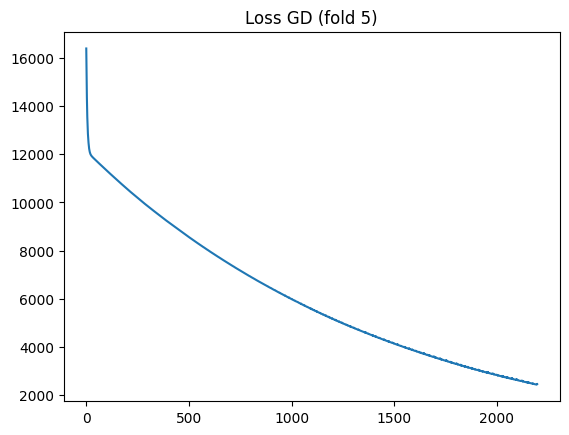

Testing SGDClassifier...
Training...
1 (batch 9/10): 69025
2 (batch 10/10): 66584
3 (batch 2/10): 63756
4 (batch 10/10): 61962
5 (batch 10/10): 59778
6 (batch 1/10): 57226
7 (batch 5/10): 55074
8 (batch 9/10): 53268
9 (batch 4/10): 51245
10 (batch 10/10): 49593
11 (batch 1/10): 47690
12 (batch 2/10): 46255
13 (batch 8/10): 44500
14 (batch 5/10): 43060
15 (batch 3/10): 41546
16 (batch 5/10): 40081
17 (batch 10/10): 38621
18 (batch 8/10): 37567
19 (batch 6/10): 36110
20 (batch 7/10): 35625
21 (batch 1/10): 33656
22 (batch 1/10): 32266
23 (batch 6/10): 31130
24 (batch 3/10): 30791
25 (batch 5/10): 29727
26 (batch 4/10): 28702
27 (batch 9/10): 27087
28 (batch 5/10): 26771
29 (batch 1/10): 25852
30 (batch 9/10): 24426
31 (batch 6/10): 23574
32 (batch 9/10): 23010
33 (batch 4/10): 22008
34 (batch 7/10): 21501
35 (batch 3/10): 20554
36 (batch 1/10): 20502
37 (batch 7/10): 19212
38 (batch 3/10): 19163
39 (batch 4/10): 18520
40 (batch 6/10): 17486
41 (batch 1/10): 16896
42 (batch 6/10): 16240
4

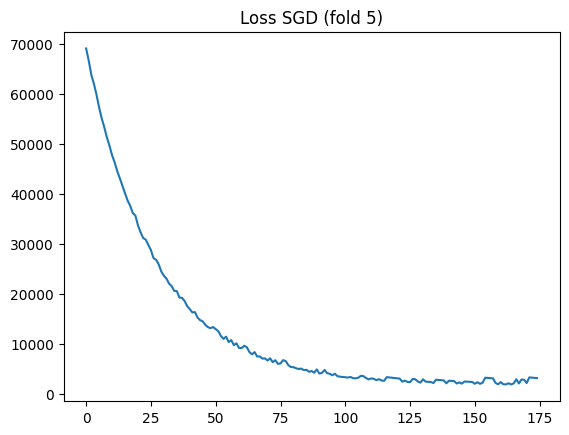

Testing SGDClassifierExponentialLR...
Training...
Epoch 1, batch 7/10, γ = 1.9e+00: 2852
Epoch 2, batch 6/10, γ = 1.8e+00: 1993
Epoch 3, batch 3/10, γ = 1.8e+00: 1667
Epoch 4, batch 1/10, γ = 1.7e+00: 2470
Patience: 9
Epoch 5, batch 3/10, γ = 1.6e+00: 2470
Patience: 8
Epoch 6, batch 1/10, γ = 1.6e+00: 2470
Patience: 7
Epoch 7, batch 9/10, γ = 1.5e+00: 1713
Patience: 6
Epoch 8, batch 1/10, γ = 1.4e+00: 2415
Patience: 5
Epoch 9, batch 9/10, γ = 1.4e+00: 1703
Patience: 4
Epoch 10, batch 3/10, γ = 1.3e+00: 2370
Patience: 3
Epoch 11, batch 6/10, γ = 1.3e+00: 1922
Patience: 2
Epoch 12, batch 4/10, γ = 1.2e+00: 1927
Patience: 1
Epoch 13, batch 5/10, γ = 1.2e+00: 1927
Patience: 0
Test set accuracy: 0.0%, Time taken: 0.01 seconds


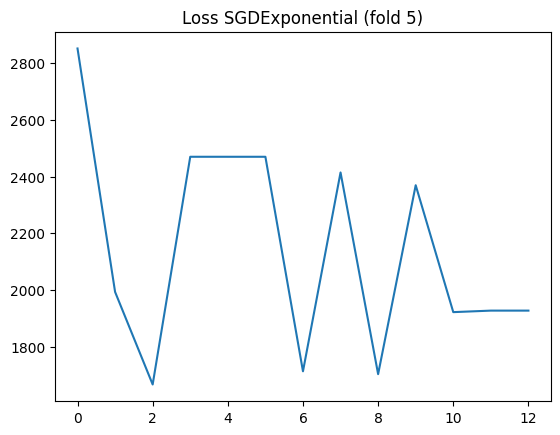

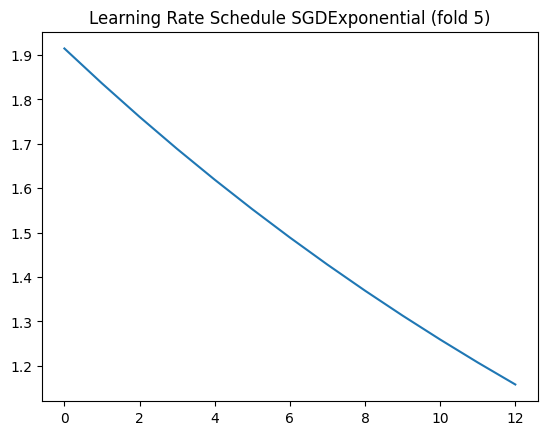

 60%|██████    | 6/10 [17:11<09:37, 144.41s/it]

Fold 7/10: Fitting and embedding BoW...


100%|██████████| 200/200 [00:00<00:00, 558.46it/s]


Fold 7/10: Fitting and embedding TFIDF...


100%|██████████| 200/200 [00:00<00:00, 360.79it/s]


Testing GDClassifier...
Training...
1: 12135
2: 12106
3: 12081
4: 12062
5: 12044
6: 12029
7: 12015
8: 12002
9: 11990
10: 11979
11: 11968
12: 11957
13: 11947
14: 11937
15: 11927
16: 11917
17: 11908
18: 11898
19: 11889
20: 11880
21: 11871
22: 11862
23: 11853
24: 11844
25: 11835
26: 11826
27: 11817
28: 11808
29: 11799
30: 11790
31: 11781
32: 11773
33: 11764
34: 11755
35: 11746
36: 11737
37: 11729
38: 11720
39: 11711
40: 11702
41: 11693
42: 11685
43: 11676
44: 11667
45: 11659
46: 11650
47: 11642
48: 11633
49: 11624
50: 11616
51: 11607
52: 11599
53: 11590
54: 11582
55: 11573
56: 11564
57: 11556
58: 11547
59: 11539
60: 11530
61: 11522
62: 11513
63: 11505
64: 11496
65: 11487
66: 11479
67: 11470
68: 11462
69: 11453
70: 11445
71: 11436
72: 11428
73: 11419
74: 11411
75: 11402
76: 11394
77: 11385
78: 11377
79: 11368
80: 11360
81: 11351
82: 11343
83: 11334
84: 11326
85: 11318
86: 11309
87: 11301
88: 11293
89: 11284
90: 11276
91: 11268
92: 11259
93: 11251
94: 11243
95: 11234
96: 11226
97: 11218
98:

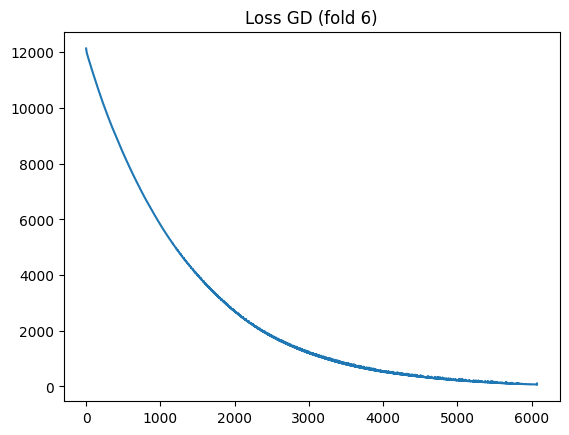

Testing SGDClassifier...
Training...
1 (batch 5/10): 68299
2 (batch 10/10): 65842
3 (batch 7/10): 63822
4 (batch 3/10): 61258
5 (batch 5/10): 59126
6 (batch 1/10): 57030
7 (batch 1/10): 55011
8 (batch 7/10): 53065
9 (batch 8/10): 51524
10 (batch 9/10): 49902
11 (batch 4/10): 47697
12 (batch 3/10): 45875
13 (batch 10/10): 44421
14 (batch 10/10): 43328
15 (batch 8/10): 41823
16 (batch 8/10): 40372
17 (batch 3/10): 38537
18 (batch 9/10): 37623
19 (batch 10/10): 36344
20 (batch 5/10): 34667
21 (batch 6/10): 33445
22 (batch 6/10): 32266
23 (batch 6/10): 31131
24 (batch 5/10): 30308
25 (batch 5/10): 29255
26 (batch 4/10): 28245
27 (batch 9/10): 27093
28 (batch 10/10): 26410
29 (batch 2/10): 25278
30 (batch 9/10): 24660
31 (batch 5/10): 23594
32 (batch 2/10): 22991
33 (batch 8/10): 22038
34 (batch 7/10): 21538
35 (batch 10/10): 21762
Patience: 9
36 (batch 3/10): 20094
37 (batch 1/10): 19199
38 (batch 8/10): 18796
39 (batch 9/10): 19111
Patience: 9
40 (batch 4/10): 17581
41 (batch 7/10): 17903

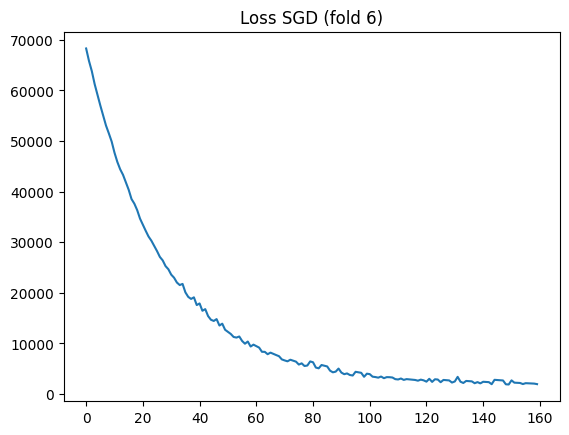

Testing SGDClassifierExponentialLR...
Training...
Epoch 1, batch 3/10, γ = 1.9e+00: 2232
Epoch 2, batch 10/10, γ = 1.8e+00: 1832
Epoch 3, batch 2/10, γ = 1.8e+00: 2171
Patience: 9
Epoch 4, batch 9/10, γ = 1.7e+00: 1817
Epoch 5, batch 8/10, γ = 1.6e+00: 2635
Patience: 9
Epoch 6, batch 6/10, γ = 1.6e+00: 1970
Patience: 8
Epoch 7, batch 6/10, γ = 1.5e+00: 1932
Patience: 7
Epoch 8, batch 1/10, γ = 1.4e+00: 1655
Epoch 9, batch 5/10, γ = 1.4e+00: 2453
Patience: 9
Epoch 10, batch 5/10, γ = 1.3e+00: 2453
Patience: 8
Epoch 11, batch 9/10, γ = 1.3e+00: 1664
Patience: 7
Epoch 12, batch 1/10, γ = 1.2e+00: 2384
Patience: 6
Epoch 13, batch 8/10, γ = 1.2e+00: 1661
Patience: 5
Epoch 14, batch 6/10, γ = 1.1e+00: 1654
Epoch 15, batch 9/10, γ = 1.1e+00: 1855
Patience: 9
Epoch 16, batch 1/10, γ = 1.0e+00: 1657
Patience: 8
Epoch 17, batch 8/10, γ = 9.8e-01: 1846
Patience: 7
Epoch 18, batch 10/10, γ = 9.4e-01: 2117
Patience: 6
Epoch 19, batch 2/10, γ = 9.0e-01: 1854
Patience: 5
Epoch 20, batch 3/10, γ = 8.6

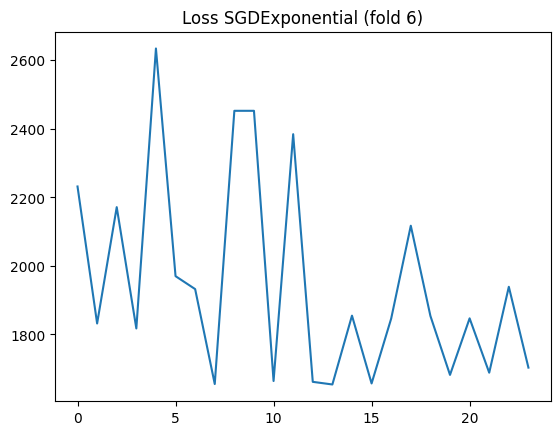

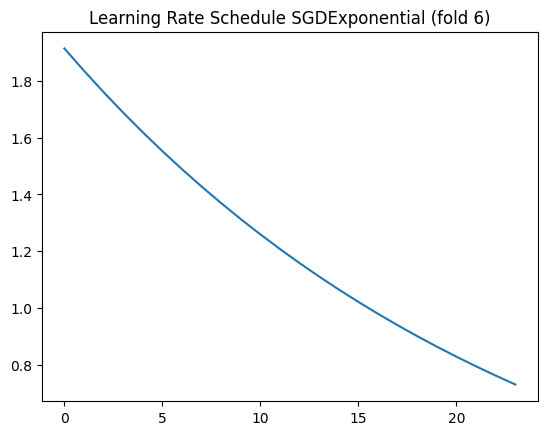

 70%|███████   | 7/10 [21:18<08:53, 177.87s/it]

Fold 8/10: Fitting and embedding BoW...


100%|██████████| 200/200 [00:00<00:00, 551.52it/s]


Fold 8/10: Fitting and embedding TFIDF...


100%|██████████| 200/200 [00:00<00:00, 367.52it/s]


Testing GDClassifier...
Training...
1: 12858
2: 12803
3: 12754
4: 12714
5: 12681
6: 12655
7: 12635
8: 12618
9: 12603
10: 12590
11: 12577
12: 12565
13: 12553
14: 12543
15: 12532
16: 12522
17: 12512
18: 12502
19: 12493
20: 12484
21: 12474
22: 12465
23: 12456
24: 12448
25: 12439
26: 12430
27: 12422
28: 12413
29: 12404
30: 12396
31: 12387
32: 12379
33: 12370
34: 12362
35: 12354
36: 12345
37: 12337
38: 12328
39: 12320
40: 12312
41: 12304
42: 12295
43: 12287
44: 12279
45: 12270
46: 12262
47: 12254
48: 12246
49: 12237
50: 12229
51: 12221
52: 12212
53: 12204
54: 12196
55: 12188
56: 12179
57: 12171
58: 12163
59: 12155
60: 12146
61: 12138
62: 12130
63: 12122
64: 12114
65: 12105
66: 12097
67: 12089
68: 12081
69: 12073
70: 12065
71: 12057
72: 12049
73: 12041
74: 12032
75: 12024
76: 12016
77: 12008
78: 12000
79: 11992
80: 11984
81: 11976
82: 11968
83: 11960
84: 11952
85: 11944
86: 11936
87: 11928
88: 11920
89: 11911
90: 11903
91: 11895
92: 11887
93: 11879
94: 11871
95: 11863
96: 11855
97: 11847
98:

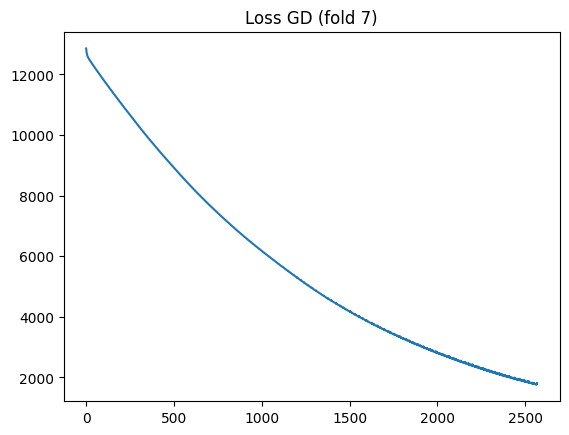

Testing SGDClassifier...
Training...
1 (batch 6/10): 69059
2 (batch 8/10): 67032
3 (batch 4/10): 64064
4 (batch 7/10): 62384
5 (batch 4/10): 59610
6 (batch 10/10): 58067
7 (batch 1/10): 55474
8 (batch 10/10): 54057
9 (batch 3/10): 51633
10 (batch 1/10): 49619
11 (batch 9/10): 48075
12 (batch 7/10): 46916
13 (batch 10/10): 45269
14 (batch 1/10): 43196
15 (batch 1/10): 41502
16 (batch 6/10): 40057
17 (batch 2/10): 39320
18 (batch 10/10): 37324
19 (batch 7/10): 36259
20 (batch 8/10): 35748
21 (batch 2/10): 33794
22 (batch 6/10): 32605
23 (batch 2/10): 31256
24 (batch 1/10): 30916
25 (batch 4/10): 29848
26 (batch 1/10): 28818
27 (batch 1/10): 27825
28 (batch 4/10): 26867
29 (batch 6/10): 25530
30 (batch 9/10): 24632
31 (batch 1/10): 23814
32 (batch 3/10): 22994
33 (batch 4/10): 22204
34 (batch 8/10): 21495
35 (batch 5/10): 20724
36 (batch 1/10): 20031
37 (batch 3/10): 19368
38 (batch 4/10): 18709
39 (batch 7/10): 18169
40 (batch 3/10): 17479
41 (batch 1/10): 16929
42 (batch 7/10): 16443
43

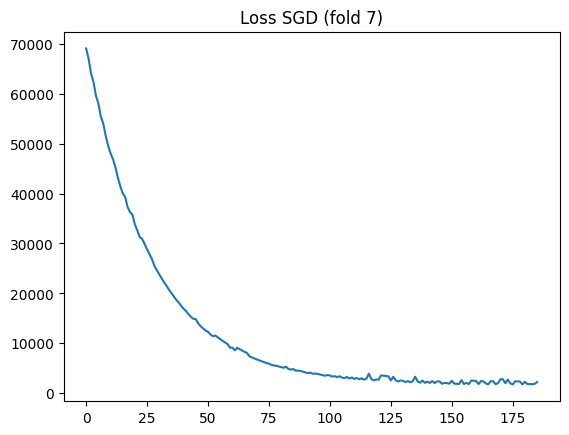

Testing SGDClassifierExponentialLR...
Training...
Epoch 1, batch 3/10, γ = 1.9e+00: 2823
Epoch 2, batch 4/10, γ = 1.8e+00: 2823
Epoch 3, batch 10/10, γ = 1.8e+00: 1670
Epoch 4, batch 6/10, γ = 1.7e+00: 1654
Epoch 5, batch 3/10, γ = 1.6e+00: 2514
Patience: 9
Epoch 6, batch 4/10, γ = 1.6e+00: 2514
Patience: 8
Epoch 7, batch 2/10, γ = 1.5e+00: 2514
Patience: 7
Epoch 8, batch 7/10, γ = 1.4e+00: 1680
Patience: 6
Epoch 9, batch 1/10, γ = 1.4e+00: 2455
Patience: 5
Epoch 10, batch 7/10, γ = 1.3e+00: 1672
Patience: 4
Epoch 11, batch 1/10, γ = 1.3e+00: 2378
Patience: 3
Epoch 12, batch 9/10, γ = 1.2e+00: 1671
Patience: 2
Epoch 13, batch 2/10, γ = 1.2e+00: 2323
Patience: 1
Epoch 14, batch 7/10, γ = 1.1e+00: 1666
Patience: 0
Test set accuracy: 0.0%, Time taken: 0.01 seconds


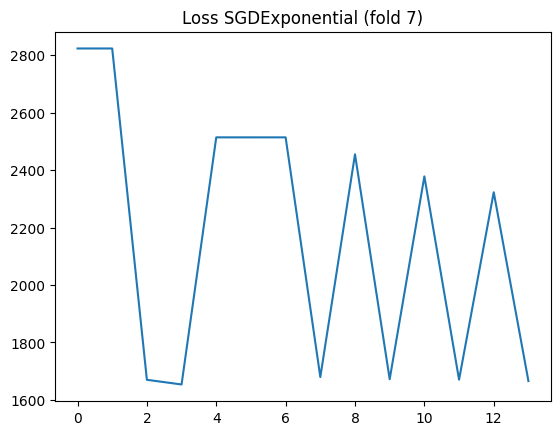

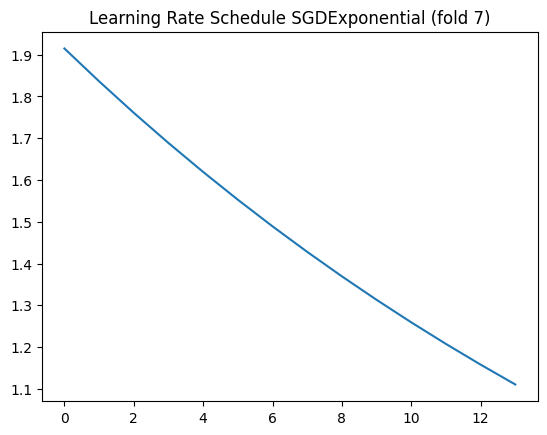

 80%|████████  | 8/10 [23:29<05:26, 163.05s/it]

Fold 9/10: Fitting and embedding BoW...


100%|██████████| 200/200 [00:00<00:00, 479.30it/s]


Fold 9/10: Fitting and embedding TFIDF...


100%|██████████| 200/200 [00:00<00:00, 364.73it/s]


Testing GDClassifier...
Training...
1: 13015
2: 12974
3: 12939
4: 12908
5: 12881
6: 12857
7: 12836
8: 12818
9: 12801
10: 12786
11: 12773
12: 12762
13: 12751
14: 12740
15: 12730
16: 12720
17: 12711
18: 12701
19: 12691
20: 12682
21: 12672
22: 12663
23: 12654
24: 12645
25: 12635
26: 12626
27: 12617
28: 12608
29: 12599
30: 12590
31: 12581
32: 12572
33: 12563
34: 12554
35: 12545
36: 12537
37: 12528
38: 12519
39: 12510
40: 12501
41: 12492
42: 12483
43: 12474
44: 12466
45: 12457
46: 12448
47: 12440
48: 12431
49: 12422
50: 12413
51: 12405
52: 12396
53: 12387
54: 12379
55: 12370
56: 12361
57: 12353
58: 12344
59: 12335
60: 12327
61: 12318
62: 12309
63: 12301
64: 12292
65: 12284
66: 12275
67: 12267
68: 12258
69: 12249
70: 12241
71: 12232
72: 12224
73: 12215
74: 12207
75: 12198
76: 12190
77: 12181
78: 12173
79: 12164
80: 12156
81: 12148
82: 12139
83: 12131
84: 12122
85: 12114
86: 12106
87: 12097
88: 12089
89: 12080
90: 12072
91: 12064
92: 12055
93: 12047
94: 12039
95: 12030
96: 12022
97: 12014
98:

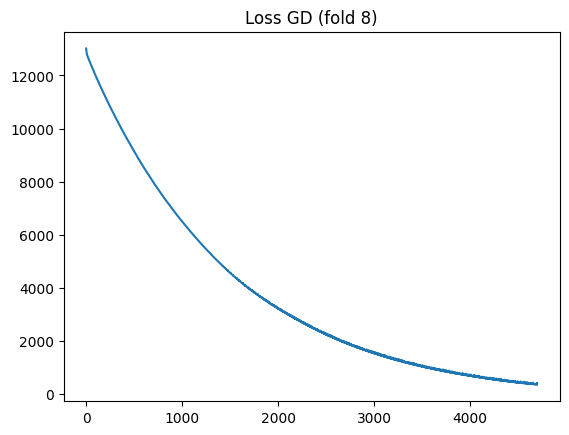

Testing SGDClassifier...
Training...
1 (batch 5/10): 68777
2 (batch 7/10): 66565
3 (batch 10/10): 64883
4 (batch 8/10): 62585
5 (batch 10/10): 60383
6 (batch 2/10): 57628
7 (batch 4/10): 55371
8 (batch 3/10): 54115
9 (batch 4/10): 52201
10 (batch 2/10): 50356
11 (batch 3/10): 48579
12 (batch 2/10): 46865
13 (batch 7/10): 44695
14 (batch 9/10): 43363
15 (batch 3/10): 41619
16 (batch 4/10): 40675
17 (batch 3/10): 39248
18 (batch 5/10): 37872
19 (batch 7/10): 36133
20 (batch 2/10): 35286
21 (batch 2/10): 34054
22 (batch 4/10): 32866
23 (batch 8/10): 31405
24 (batch 4/10): 30634
25 (batch 10/10): 29290
26 (batch 5/10): 28561
27 (batch 10/10): 27326
28 (batch 7/10): 26629
29 (batch 10/10): 26699
Patience: 9
30 (batch 6/10): 25152
31 (batch 7/10): 24295
32 (batch 4/10): 23067
33 (batch 9/10): 22694
34 (batch 4/10): 21543
35 (batch 9/10): 21207
36 (batch 9/10): 20499
37 (batch 9/10): 19823
38 (batch 8/10): 19178
39 (batch 3/10): 18192
40 (batch 2/10): 17545
41 (batch 1/10): 16957
42 (batch 9/

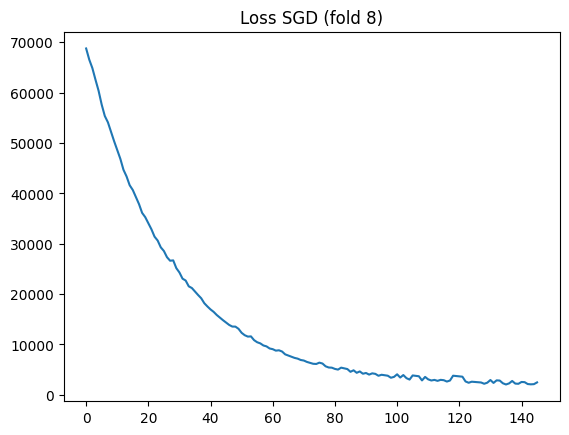

Testing SGDClassifierExponentialLR...
Training...
Epoch 1, batch 9/10, γ = 1.9e+00: 3615
Epoch 2, batch 5/10, γ = 1.8e+00: 1974
Epoch 3, batch 6/10, γ = 1.8e+00: 1932
Epoch 4, batch 7/10, γ = 1.7e+00: 3262
Patience: 9
Epoch 5, batch 8/10, γ = 1.6e+00: 3262
Patience: 8
Epoch 6, batch 8/10, γ = 1.6e+00: 3262
Patience: 7
Epoch 7, batch 9/10, γ = 1.5e+00: 3262
Patience: 6
Epoch 8, batch 2/10, γ = 1.4e+00: 1988
Patience: 5
Epoch 9, batch 9/10, γ = 1.4e+00: 3096
Patience: 4
Epoch 10, batch 5/10, γ = 1.3e+00: 1975
Patience: 3
Epoch 11, batch 1/10, γ = 1.3e+00: 1722
Epoch 12, batch 8/10, γ = 1.2e+00: 1964
Patience: 9
Epoch 13, batch 6/10, γ = 1.2e+00: 1938
Patience: 8
Epoch 14, batch 6/10, γ = 1.1e+00: 1913
Patience: 7
Epoch 15, batch 8/10, γ = 1.1e+00: 2544
Patience: 6
Epoch 16, batch 2/10, γ = 1.0e+00: 1922
Patience: 5
Epoch 17, batch 4/10, γ = 9.8e-01: 1726
Patience: 4
Epoch 18, batch 10/10, γ = 9.4e-01: 1913
Patience: 3
Epoch 19, batch 8/10, γ = 9.0e-01: 2384
Patience: 2
Epoch 20, batch 1/

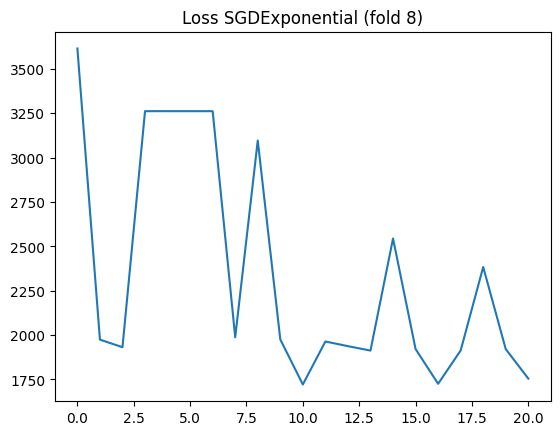

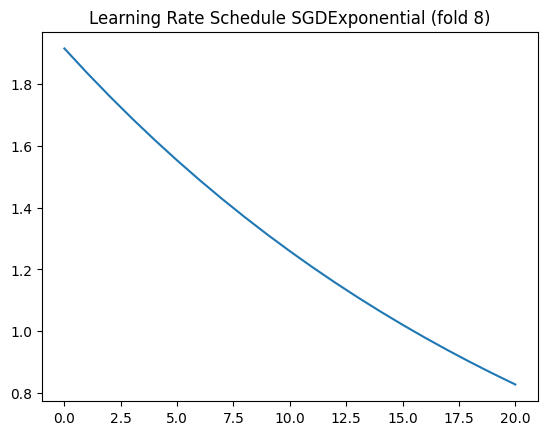

 90%|█████████ | 9/10 [26:53<02:55, 175.97s/it]

Fold 10/10: Fitting and embedding BoW...


100%|██████████| 200/200 [00:00<00:00, 514.04it/s]


Fold 10/10: Fitting and embedding TFIDF...


100%|██████████| 200/200 [00:00<00:00, 354.49it/s]


Testing GDClassifier...
Training...
1: 12602
2: 12572
3: 12546
4: 12521
5: 12499
6: 12477
7: 12458
8: 12443
9: 12428
10: 12415
11: 12403
12: 12391
13: 12379
14: 12368
15: 12357
16: 12348
17: 12338
18: 12329
19: 12321
20: 12312
21: 12304
22: 12295
23: 12287
24: 12279
25: 12270
26: 12262
27: 12254
28: 12245
29: 12237
30: 12229
31: 12221
32: 12213
33: 12205
34: 12197
35: 12188
36: 12180
37: 12172
38: 12164
39: 12156
40: 12148
41: 12140
42: 12132
43: 12124
44: 12116
45: 12108
46: 12100
47: 12092
48: 12084
49: 12076
50: 12068
51: 12060
52: 12052
53: 12044
54: 12036
55: 12028
56: 12020
57: 12012
58: 12004
59: 11996
60: 11988
61: 11980
62: 11972
63: 11964
64: 11956
65: 11948
66: 11940
67: 11932
68: 11924
69: 11916
70: 11909
71: 11901
72: 11893
73: 11885
74: 11877
75: 11869
76: 11861
77: 11853
78: 11845
79: 11837
80: 11829
81: 11822
82: 11814
83: 11806
84: 11798
85: 11790
86: 11782
87: 11774
88: 11766
89: 11759
90: 11751
91: 11743
92: 11735
93: 11727
94: 11719
95: 11712
96: 11704
97: 11696
98:

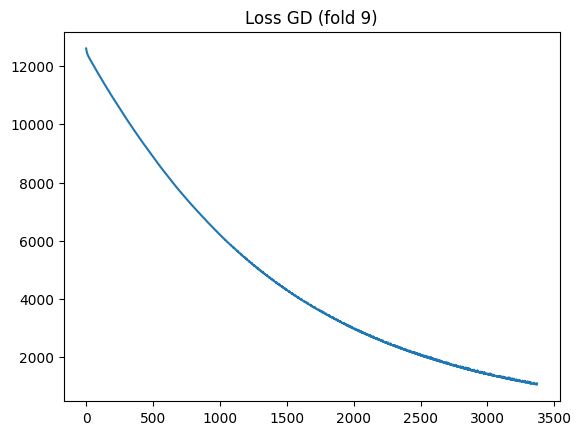

Testing SGDClassifier...
Training...
1 (batch 8/10): 69406
2 (batch 4/10): 65837
3 (batch 1/10): 63246
4 (batch 2/10): 61139
5 (batch 6/10): 58733
6 (batch 5/10): 57295
7 (batch 1/10): 55264
8 (batch 7/10): 52755
9 (batch 4/10): 51437
10 (batch 4/10): 49619
11 (batch 4/10): 47866
12 (batch 1/10): 46177
13 (batch 2/10): 44548
14 (batch 5/10): 42979
15 (batch 4/10): 41466
16 (batch 2/10): 40008
17 (batch 2/10): 38602
18 (batch 4/10): 37248
19 (batch 9/10): 35702
20 (batch 8/10): 34701
21 (batch 10/10): 34475
22 (batch 10/10): 33291
23 (batch 8/10): 32149
24 (batch 4/10): 30147
25 (batch 3/10): 28885
26 (batch 2/10): 28321
27 (batch 1/10): 27342
28 (batch 2/10): 26399
29 (batch 10/10): 25157
30 (batch 6/10): 24279
31 (batch 3/10): 23904
32 (batch 5/10): 23086
33 (batch 10/10): 21914
34 (batch 1/10): 21556
35 (batch 3/10): 20823
36 (batch 4/10): 20117
37 (batch 1/10): 19435
38 (batch 2/10): 18779
39 (batch 5/10): 18145
40 (batch 9/10): 17329
41 (batch 8/10): 16996
42 (batch 9/10): 17466
Pa

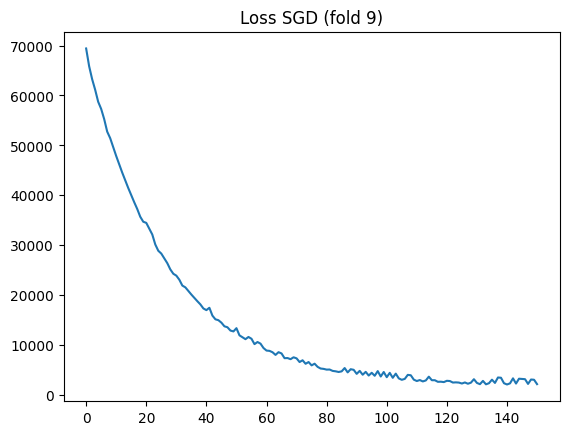

Testing SGDClassifierExponentialLR...
Training...
Epoch 1, batch 10/10, γ = 1.9e+00: 3590
Epoch 2, batch 8/10, γ = 1.8e+00: 3590
Epoch 3, batch 10/10, γ = 1.8e+00: 3590
Epoch 4, batch 7/10, γ = 1.7e+00: 3590
Epoch 5, batch 4/10, γ = 1.6e+00: 2031
Epoch 6, batch 3/10, γ = 1.6e+00: 1694
Epoch 7, batch 10/10, γ = 1.5e+00: 2004
Patience: 9
Epoch 8, batch 10/10, γ = 1.4e+00: 3009
Patience: 8
Epoch 9, batch 9/10, γ = 1.4e+00: 3009
Patience: 7
Epoch 10, batch 6/10, γ = 1.3e+00: 2282
Patience: 6
Epoch 11, batch 1/10, γ = 1.3e+00: 1813
Patience: 5
Epoch 12, batch 4/10, γ = 1.2e+00: 1781
Patience: 4
Epoch 13, batch 9/10, γ = 1.2e+00: 1803
Patience: 3
Epoch 14, batch 2/10, γ = 1.1e+00: 1742
Patience: 2
Epoch 15, batch 5/10, γ = 1.1e+00: 1821
Patience: 1
Epoch 16, batch 3/10, γ = 1.0e+00: 1847
Patience: 0
Test set accuracy: 0.0%, Time taken: 0.01 seconds


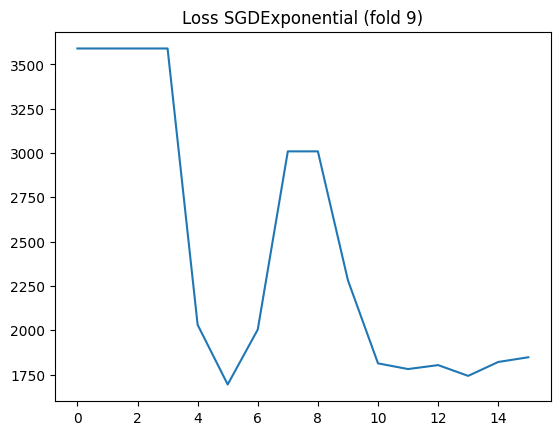

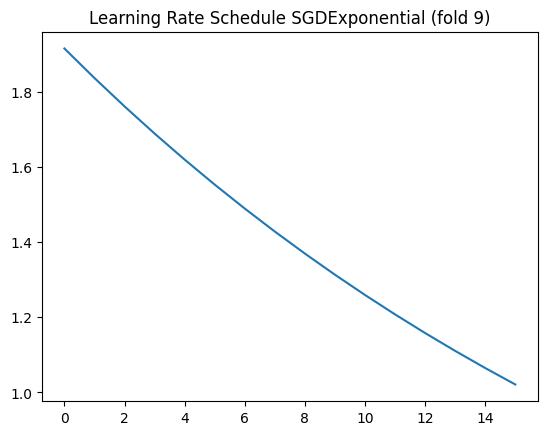

100%|██████████| 10/10 [29:33<00:00, 177.36s/it]


Final Results:
GD: Average Accuracy = 45.75%, Average Duration = 0.01 seconds
SGD: Average Accuracy = 70.00%, Average Duration = 0.01 seconds
SGDExponential: Average Accuracy = 20.00%, Average Duration = 0.01 seconds


In [ ]:
# hardcodat körde optimiseringen separat pga lång
best_regularizer_dampening_gd = 0.00001
best_learning_rate_gd = 0.0000289

verbose = True
patience = 10

results = {"GD": [], "SGD": [], "SGDExponential": []}
K = 10
n = len(X_raw_shuffled)
fold_size = n // K # floor it for now

for k in tqdm(range(K), total=K):
    # Splitta
    start = k * fold_size
    end = (k + 1) * fold_size if k < K - 1 else n # last fold (k = K-1) gets eventual remainder
    
    X_test = X_raw_shuffled[start:end]
    y_test = y[start:end]

    X_train = X_raw_shuffled[:start] + X_raw_shuffled[end:]  # X_train är en lista
    y_train = np.concatenate((y[:start], y[end:]), axis=0) # y_train är en numpy array
    
    # Embedda bow för gd
    vectorizer_bow = CountVectorizer()
    print(f"Fold {k+1}/{K}: Fitting and embedding BoW...")
    vectorizer_bow.fit(X_train)
    X_train_bow = vectorizer_bow.transform(X_train)
    X_test_bow = vectorizer_bow.transform(X_test)

    # Embedda tfidf för sgd och sgde
    vectorizer_tfidf = CountVectorizerTFIDF()
    print(f"Fold {k+1}/{K}: Fitting and embedding TFIDF...")
    vectorizer_tfidf.fit(X_train)
    X_train_tfidf = vectorizer_tfidf.transform(X_train)
    X_test_tfidf = vectorizer_tfidf.transform(X_test)

    results["GD"].append(model_test(k=k, X_train=X_train_bow, X_test=X_test_bow, model_type="GD", regularizer_dampening=best_regularizer_dampening_gd, learning_rate=best_learning_rate_gd, tolerance=0.001, patience=5, verbose=verbose))
    results["SGD"].append(model_test(k=k, X_train=X_train_tfidf, X_test=X_test_tfidf, model_type="SGD", regularizer_dampening=best_regularizer_dampening_sgd, learning_rate=best_learning_rate_sgd, batches=10, tolerance=best_tolerance_sgd, patience=patience, verbose=verbose))
    results["SGDExponential"].append(model_test(k=k, X_train=X_train_tfidf, X_test=X_test_tfidf, model_type="SGDExponential", regularizer_dampening=best_regularizer_dampening_sgde, batches=10, initial_lr=initial_lr_sgde, decay_rate=decay_rate_sgde, tolerance=best_tolerance_sgde, patience=patience, verbose=verbose))

print("\nFinal Results:")
for model_type in results:
    accuracies = [acc for acc, _ in results[model_type]]
    durations = [dur for _, dur in results[model_type]]
    avg_acc = np.mean(accuracies)
    avg_dur = np.mean(durations)
    print(f"{model_type}: Average Accuracy = {avg_acc*100:.2f}%, Average Duration = {avg_dur:.2f} seconds")